In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from config import (
    WP_FIDUCIAL_PATH,
    WP_JACKKNIFE_PATH,
    DERIVATIVES_DIR,
)

print("Analysis notebook initialized.")
print(f"Fiducial wp file: {WP_FIDUCIAL_PATH}")
print(f"Jackknife file:   {WP_JACKKNIFE_PATH}")
print(f"Derivatives dir:  {DERIVATIVES_DIR}")

Analysis notebook initialized.
Fiducial wp file: results/wp_fiducial.npz
Jackknife file:   results/wp_jackknife_njn100.npz
Derivatives dir:  results/derivatives


In [2]:
import numpy as np
from pathlib import Path

from config import (
    WP_FIDUCIAL_PATH,
    WP_JACKKNIFE_PATH,
    DERIVATIVES_DIR,
)

# ------------------------------------------------------------
# Load fiducial wp(rp)
# ------------------------------------------------------------
fid = np.load(WP_FIDUCIAL_PATH)

rp = fid["rp"]
wp_fid = fid["wp"]

# ------------------------------------------------------------
# Load jackknife results
# ------------------------------------------------------------
jk = np.load(WP_JACKKNIFE_PATH)

rp_jk = jk["rp"]
wp_mean = jk["wp_mean"]
cov = jk["cov"]
diag_err = jk["diag_err"]

# ------------------------------------------------------------
# Load bundled derivatives
# ------------------------------------------------------------
deriv_file = Path(DERIVATIVES_DIR) / "derivatives.npz"
derivs_file = np.load(deriv_file, allow_pickle=True)

print("Loaded:")
print(f"  Fiducial wp       : {len(wp_fid)} bins")
print(f"  Jackknife mean    : {len(wp_mean)} bins")
print(f"  Covariance        : {cov.shape}")
print(f"  Derivatives file  : {deriv_file}")
print(f"  Derivative keys   : {derivs_file.files}")

Loaded:
  Fiducial wp       : 50 bins
  Jackknife mean    : 50 bins
  Covariance        : (50, 50)
  Derivatives file  : results/derivatives/derivatives.npz
  Derivative keys   : ['rp', 'seed', 'Mr_thresh', 'param_names', 'deltas', 'mass_params', 'dwp_Mcut_5', 'dwp_Mcut_2p5', 'dwp_M1_5', 'dwp_M1_2p5', 'dwp_M0_5', 'dwp_M0_2p5', 'dwp_sigma_5', 'dwp_sigma_2p5', 'dwp_alpha_5', 'dwp_alpha_2p5']


In [3]:
print("rp consistency checks")
print("-" * 50)

print(f"Fiducial vs jackknife rp: {np.allclose(rp, rp_jk)}")

for key in derivs_file.files:
    if key.startswith("dwp_"):
        print(f"{key:<25} : {np.allclose(rp, rp_jk)}")

rp consistency checks
--------------------------------------------------
Fiducial vs jackknife rp: True
dwp_Mcut_5                : True
dwp_Mcut_2p5              : True
dwp_M1_5                  : True
dwp_M1_2p5                : True
dwp_M0_5                  : True
dwp_M0_2p5                : True
dwp_sigma_5               : True
dwp_sigma_2p5             : True
dwp_alpha_5               : True
dwp_alpha_2p5             : True


In [4]:
# Cell: Basic derivative statistics

HOD_PARAM_NAMES = ['Mcut', 'M1', 'M0', 'sigma', 'alpha']
DELTAS = [0.050, 0.025]

print("Derivative statistics")
print("=" * 75)

for param in HOD_PARAM_NAMES:
    print(f"\n{param}")
    print("-" * 75)

    for delta in DELTAS:
        tag = "5" if delta == 0.050 else "2p5"
        D = derivs_file[f"dwp_{param}_{tag}"]

        print(
            f"  ±{delta*100:.1f}% : "
            f"min={np.min(D): .5e}, "
            f"max={np.max(D): .5e}, "
            f"median={np.median(D): .5e}, "
            f"max|D|={np.max(np.abs(D)): .5e}"
        )

Derivative statistics

Mcut
---------------------------------------------------------------------------
  ±5.0% : min= 5.34491e-01, max= 3.01380e+02, median= 1.63871e+01, max|D|= 3.01380e+02
  ±2.5% : min= 2.77644e-01, max= 3.00608e+02, median= 1.61637e+01, max|D|= 3.00608e+02

M1
---------------------------------------------------------------------------
  ±5.0% : min=-3.72404e+02, max= 1.83947e-01, median=-1.10512e+01, max|D|= 3.72404e+02
  ±2.5% : min=-3.17751e+02, max= 2.34379e+00, median=-2.36286e+01, max|D|= 3.17751e+02

M0
---------------------------------------------------------------------------
  ±5.0% : min= 0.00000e+00, max= 0.00000e+00, median= 0.00000e+00, max|D|= 0.00000e+00
  ±2.5% : min= 0.00000e+00, max= 0.00000e+00, median= 0.00000e+00, max|D|= 0.00000e+00

sigma
---------------------------------------------------------------------------
  ±5.0% : min=-3.92123e+01, max= 1.09365e+00, median=-2.56601e+00, max|D|= 3.92123e+01
  ±2.5% : min=-4.81787e+01, max= 6.57417e+00

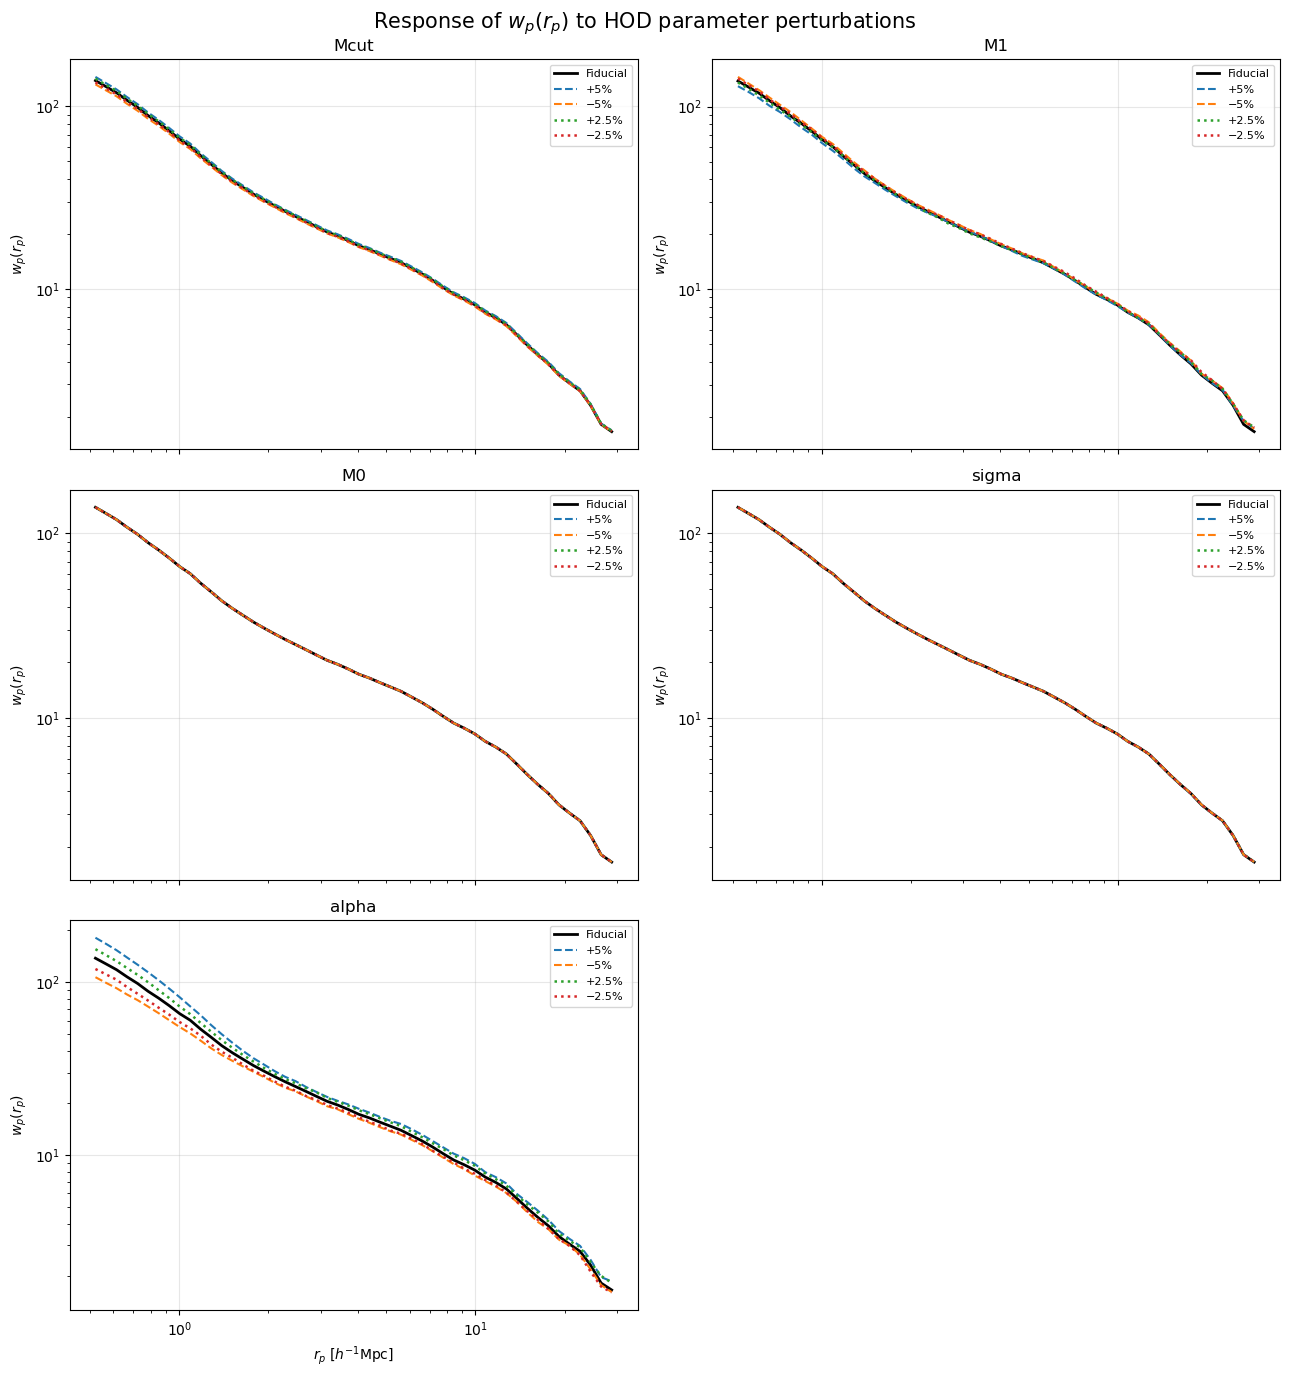

In [5]:
# Cell: wp response to HOD parameter perturbations

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

deriv_dir = Path(DERIVATIVES_DIR)

fig, axes = plt.subplots(
    3, 2,
    figsize=(13, 14),
    sharex=True
)

axes = axes.flatten()

for i, param in enumerate(HOD_PARAM_NAMES):

    ax = axes[i]

    # Fiducial
    ax.loglog(
        rp,
        wp_fid,
        'k-',
        lw=2,
        label='Fiducial'
    )

    # ±5%
    plus5 = np.load(deriv_dir / f"{param}_plus5.npz")
    minus5 = np.load(deriv_dir / f"{param}_minus5.npz")

    ax.loglog(
        plus5["rp"],
        plus5["wp"],
        '--',
        lw=1.5,
        label='+5%'
    )

    ax.loglog(
        minus5["rp"],
        minus5["wp"],
        '--',
        lw=1.5,
        label='−5%'
    )

    # ±2.5%
    plus25 = np.load(deriv_dir / f"{param}_plus2p5.npz")
    minus25 = np.load(deriv_dir / f"{param}_minus2p5.npz")

    ax.loglog(
        plus25["rp"],
        plus25["wp"],
        ':',
        lw=1.8,
        label='+2.5%'
    )

    ax.loglog(
        minus25["rp"],
        minus25["wp"],
        ':',
        lw=1.8,
        label='−2.5%'
    )

    ax.set_title(param)
    ax.set_ylabel(r"$w_p(r_p)$")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

# Remove unused sixth panel
axes[-1].axis("off")

axes[-2].set_xlabel(r"$r_p\;[h^{-1}\mathrm{Mpc}]$")

fig.suptitle(
    r"Response of $w_p(r_p)$ to HOD parameter perturbations",
    fontsize=15
)

plt.tight_layout()
plt.show()

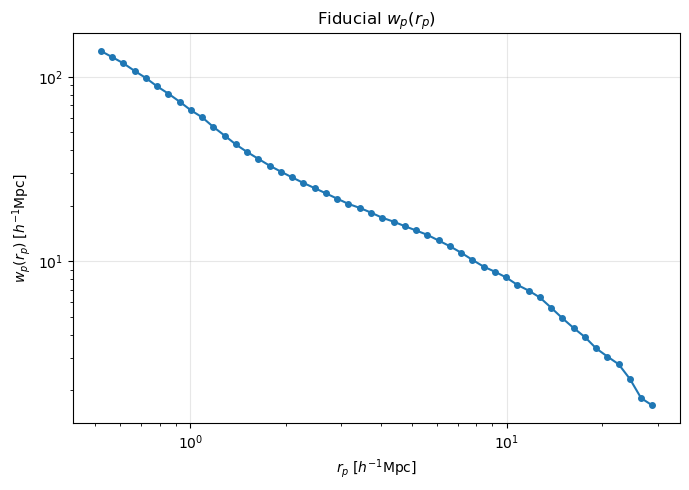

In [6]:
plt.figure(figsize=(7, 5))

plt.loglog(rp, wp_fid, 'o-', ms=4, lw=1.5)

plt.xlabel(r'$r_p\;[h^{-1}\mathrm{Mpc}]$')
plt.ylabel(r'$w_p(r_p)\;[h^{-1}\mathrm{Mpc}]$')
plt.title(r'Fiducial $w_p(r_p)$')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

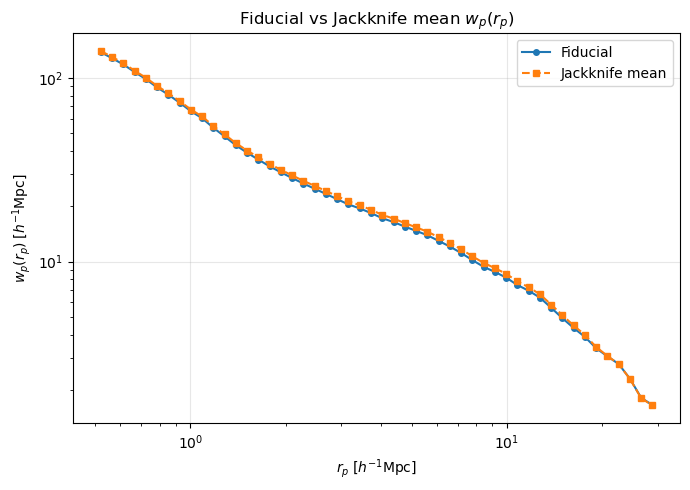

In [7]:
plt.figure(figsize=(7, 5))

plt.loglog(rp, wp_fid, 'o-', ms=4, lw=1.5, label='Fiducial')
plt.loglog(rp_jk, wp_mean, 's--', ms=4, lw=1.5, label='Jackknife mean')

plt.xlabel(r'$r_p\;[h^{-1}\mathrm{Mpc}]$')
plt.ylabel(r'$w_p(r_p)\;[h^{-1}\mathrm{Mpc}]$')
plt.title(r'Fiducial vs Jackknife mean $w_p(r_p)$')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

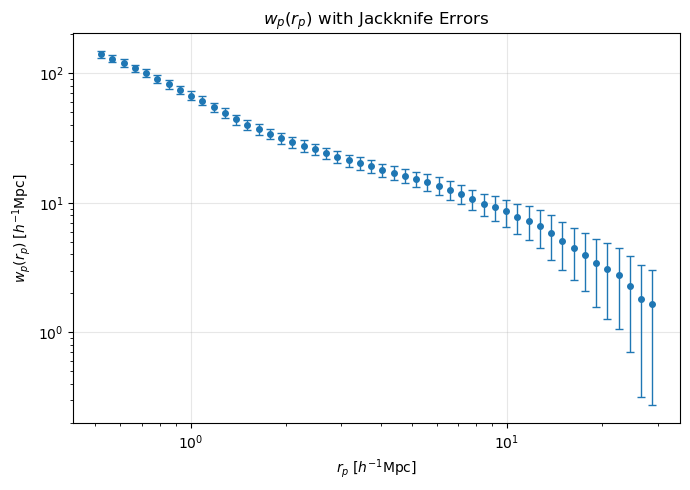

In [8]:
plt.figure(figsize=(7, 5))

plt.errorbar(
    rp_jk,
    wp_mean,
    yerr=diag_err,
    fmt='o',
    ms=4,
    capsize=3,
    lw=1
)

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'$r_p\;[h^{-1}\mathrm{Mpc}]$')
plt.ylabel(r'$w_p(r_p)\;[h^{-1}\mathrm{Mpc}]$')
plt.title(r'$w_p(r_p)$ with Jackknife Errors')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

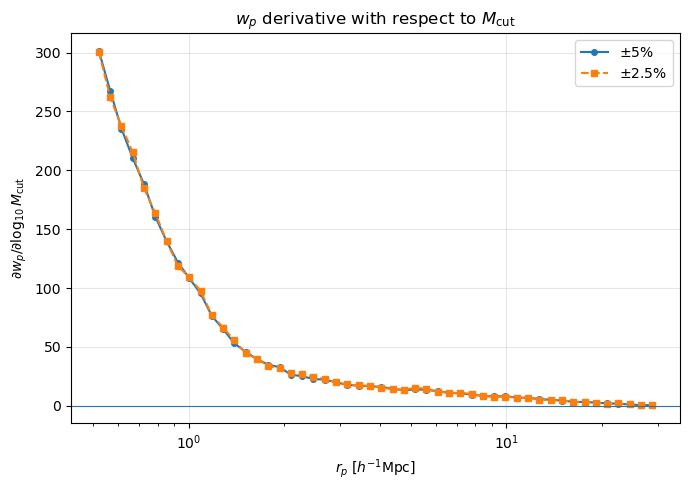

In [9]:
from pathlib import Path

D5 = derivs_file["dwp_Mcut_5"]
D25 = derivs_file["dwp_Mcut_2p5"]

plt.figure(figsize=(7, 5))

plt.plot(rp, D5, 'o-', ms=4, lw=1.5, label=r'$\pm5\%$')
plt.plot(rp, D25, 's--', ms=4, lw=1.5, label=r'$\pm2.5\%$')

plt.xscale('log')
plt.axhline(0, lw=0.8)

plt.xlabel(r'$r_p\;[h^{-1}\mathrm{Mpc}]$')
plt.ylabel(r'$\partial w_p/\partial\log_{10}M_{\rm cut}$')
plt.title(r'$w_p$ derivative with respect to $M_{\rm cut}$')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

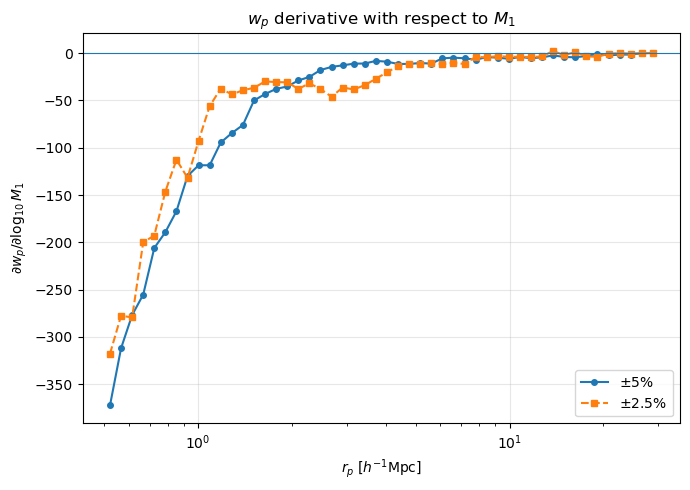

In [11]:
D5 = derivs_file["dwp_M1_5"]
D25 = derivs_file["dwp_M1_2p5"]

plt.figure(figsize=(7, 5))

plt.plot(rp, D5, 'o-', ms=4, lw=1.5, label=r'$\pm5\%$')
plt.plot(rp, D25, 's--', ms=4, lw=1.5, label=r'$\pm2.5\%$')

plt.xscale('log')
plt.axhline(0, lw=0.8)

plt.xlabel(r'$r_p\;[h^{-1}\mathrm{Mpc}]$')
plt.ylabel(r'$\partial w_p/\partial\log_{10}M_1$')
plt.title(r'$w_p$ derivative with respect to $M_1$')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

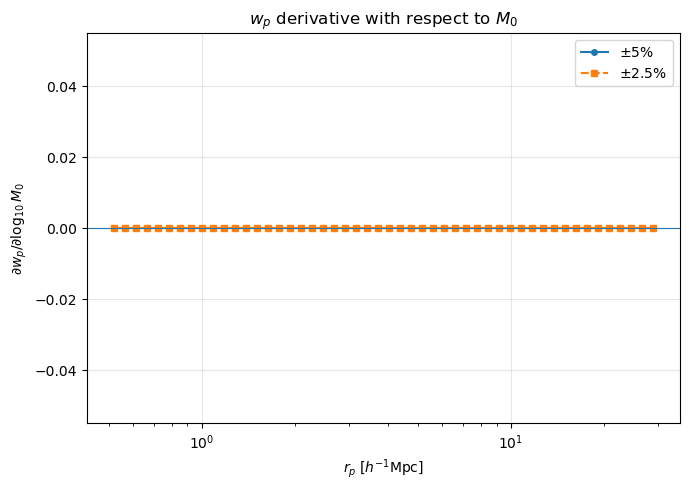

In [12]:
D5 = derivs_file["dwp_M0_5"]
D25 = derivs_file["dwp_M0_2p5"]

plt.figure(figsize=(7, 5))

plt.plot(rp, D5, 'o-', ms=4, lw=1.5, label=r'$\pm5\%$')
plt.plot(rp, D25, 's--', ms=4, lw=1.5, label=r'$\pm2.5\%$')

plt.xscale('log')
plt.axhline(0, lw=0.8)

plt.xlabel(r'$r_p\;[h^{-1}\mathrm{Mpc}]$')
plt.ylabel(r'$\partial w_p/\partial\log_{10}M_0$')
plt.title(r'$w_p$ derivative with respect to $M_0$')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

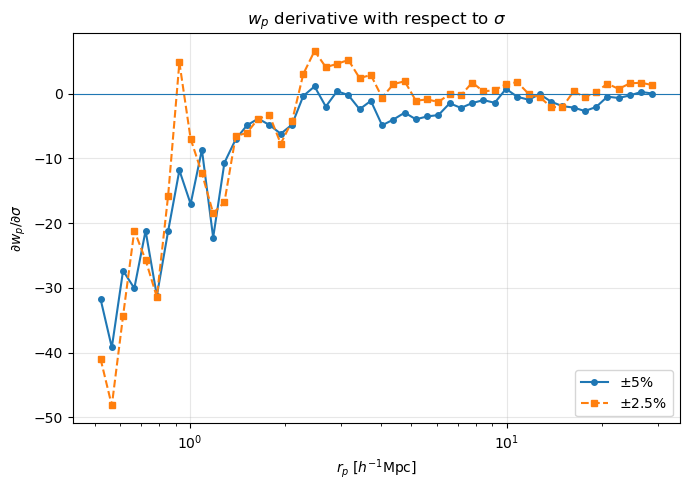

In [13]:
D5 = derivs_file["dwp_sigma_5"]
D25 = derivs_file["dwp_sigma_2p5"]

plt.figure(figsize=(7, 5))

plt.plot(rp, D5, 'o-', ms=4, lw=1.5, label=r'$\pm5\%$')
plt.plot(rp, D25, 's--', ms=4, lw=1.5, label=r'$\pm2.5\%$')

plt.xscale('log')
plt.axhline(0, lw=0.8)

plt.xlabel(r'$r_p\;[h^{-1}\mathrm{Mpc}]$')
plt.ylabel(r'$\partial w_p/\partial\sigma$')
plt.title(r'$w_p$ derivative with respect to $\sigma$')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

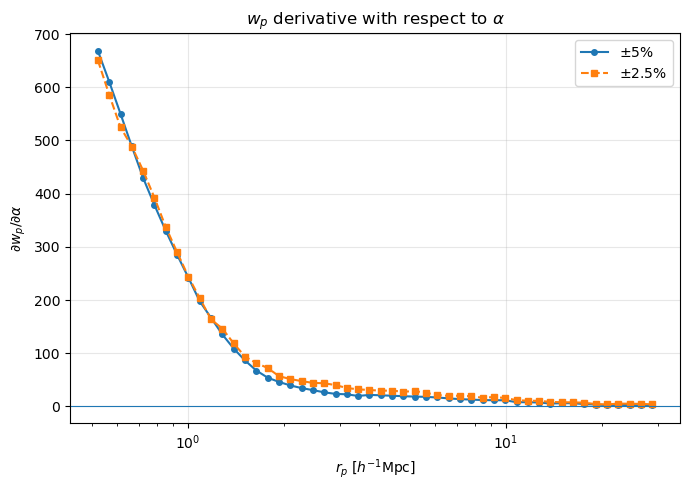

In [14]:
D5 = derivs_file["dwp_alpha_5"]
D25 = derivs_file["dwp_alpha_2p5"]

plt.figure(figsize=(7, 5))

plt.plot(rp, D5, 'o-', ms=4, lw=1.5, label=r'$\pm5\%$')
plt.plot(rp, D25, 's--', ms=4, lw=1.5, label=r'$\pm2.5\%$')

plt.xscale('log')
plt.axhline(0, lw=0.8)

plt.xlabel(r'$r_p\;[h^{-1}\mathrm{Mpc}]$')
plt.ylabel(r'$\partial w_p/\partial\alpha$')
plt.title(r'$w_p$ derivative with respect to $\alpha$')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

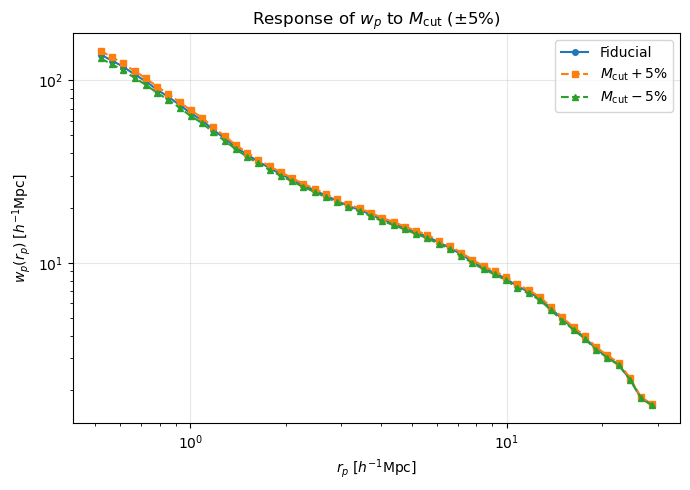

In [15]:
from pathlib import Path

base = np.load(WP_FIDUCIAL_PATH)

mcut_p5 = np.load(Path(DERIVATIVES_DIR) / "Mcut_plus5.npz")
mcut_m5 = np.load(Path(DERIVATIVES_DIR) / "Mcut_minus5.npz")

plt.figure(figsize=(7, 5))

plt.loglog(base["rp"], base["wp"], 'o-', ms=4, lw=1.5,
           label='Fiducial')
plt.loglog(mcut_p5["rp"], mcut_p5["wp"], 's--', ms=4, lw=1.5,
           label=r'$M_{\rm cut}+5\%$')
plt.loglog(mcut_m5["rp"], mcut_m5["wp"], '^--', ms=4, lw=1.5,
           label=r'$M_{\rm cut}-5\%$')

plt.xlabel(r'$r_p\;[h^{-1}\mathrm{Mpc}]$')
plt.ylabel(r'$w_p(r_p)\;[h^{-1}\mathrm{Mpc}]$')
plt.title(r'Response of $w_p$ to $M_{\rm cut}$ ($\pm5\%$)')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

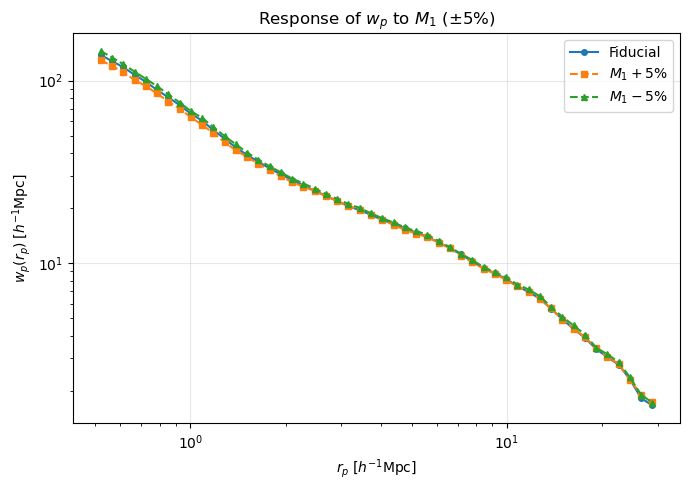

In [16]:
m1_p5 = np.load(Path(DERIVATIVES_DIR) / "M1_plus5.npz")
m1_m5 = np.load(Path(DERIVATIVES_DIR) / "M1_minus5.npz")

plt.figure(figsize=(7, 5))

plt.loglog(base["rp"], base["wp"], 'o-', ms=4, lw=1.5,
           label='Fiducial')
plt.loglog(m1_p5["rp"], m1_p5["wp"], 's--', ms=4, lw=1.5,
           label=r'$M_1+5\%$')
plt.loglog(m1_m5["rp"], m1_m5["wp"], '^--', ms=4, lw=1.5,
           label=r'$M_1-5\%$')

plt.xlabel(r'$r_p\;[h^{-1}\mathrm{Mpc}]$')
plt.ylabel(r'$w_p(r_p)\;[h^{-1}\mathrm{Mpc}]$')
plt.title(r'Response of $w_p$ to $M_1$ ($\pm5\%$)')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

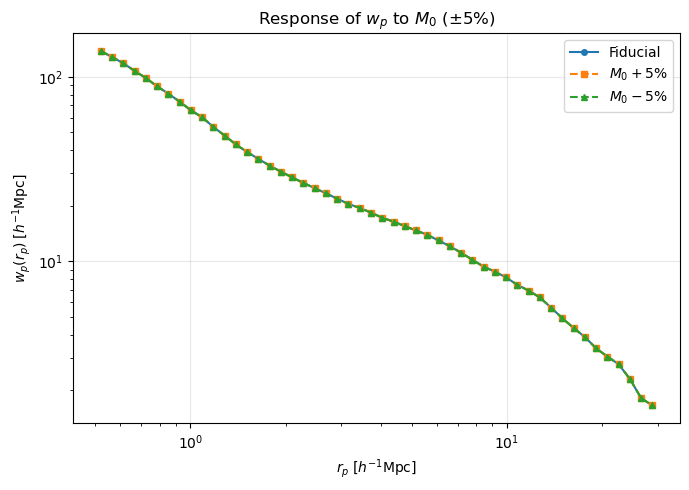

In [17]:
m0_p5 = np.load(Path(DERIVATIVES_DIR) / "M0_plus5.npz")
m0_m5 = np.load(Path(DERIVATIVES_DIR) / "M0_minus5.npz")

plt.figure(figsize=(7, 5))

plt.loglog(base["rp"], base["wp"], 'o-', ms=4, lw=1.5,
           label='Fiducial')
plt.loglog(m0_p5["rp"], m0_p5["wp"], 's--', ms=4, lw=1.5,
           label=r'$M_0+5\%$')
plt.loglog(m0_m5["rp"], m0_m5["wp"], '^--', ms=4, lw=1.5,
           label=r'$M_0-5\%$')

plt.xlabel(r'$r_p\;[h^{-1}\mathrm{Mpc}]$')
plt.ylabel(r'$w_p(r_p)\;[h^{-1}\mathrm{Mpc}]$')
plt.title(r'Response of $w_p$ to $M_0$ ($\pm5\%$)')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

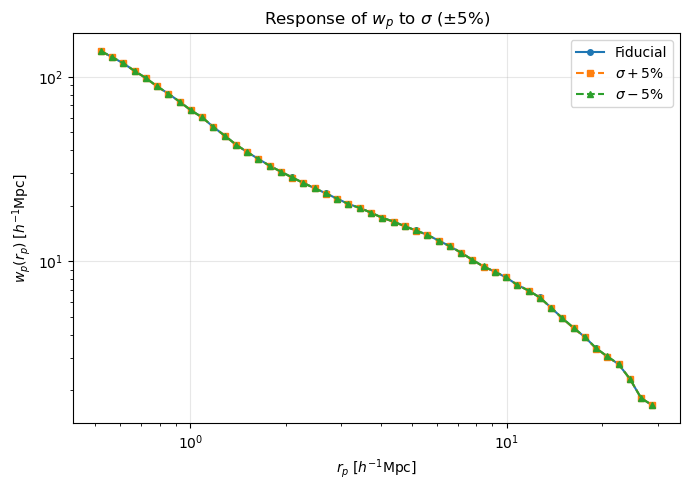

In [18]:
sigma_p5 = np.load(Path(DERIVATIVES_DIR) / "sigma_plus5.npz")
sigma_m5 = np.load(Path(DERIVATIVES_DIR) / "sigma_minus5.npz")

plt.figure(figsize=(7, 5))

plt.loglog(base["rp"], base["wp"], 'o-', ms=4, lw=1.5,
           label='Fiducial')
plt.loglog(sigma_p5["rp"], sigma_p5["wp"], 's--', ms=4, lw=1.5,
           label=r'$\sigma+5\%$')
plt.loglog(sigma_m5["rp"], sigma_m5["wp"], '^--', ms=4, lw=1.5,
           label=r'$\sigma-5\%$')

plt.xlabel(r'$r_p\;[h^{-1}\mathrm{Mpc}]$')
plt.ylabel(r'$w_p(r_p)\;[h^{-1}\mathrm{Mpc}]$')
plt.title(r'Response of $w_p$ to $\sigma$ ($\pm5\%$)')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

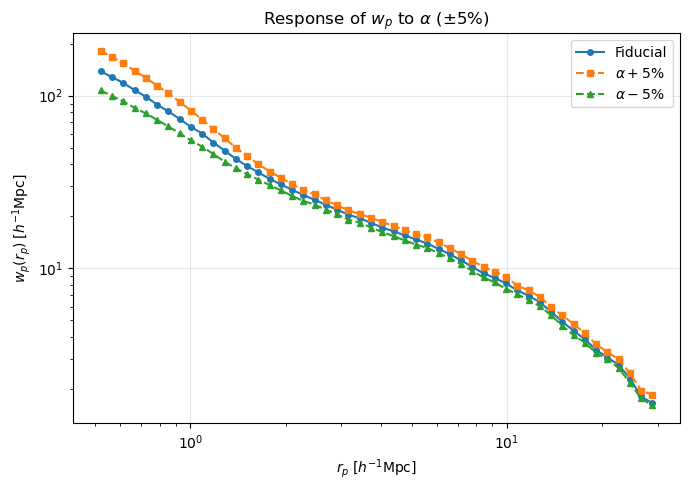

In [19]:
alpha_p5 = np.load(Path(DERIVATIVES_DIR) / "alpha_plus5.npz")
alpha_m5 = np.load(Path(DERIVATIVES_DIR) / "alpha_minus5.npz")

plt.figure(figsize=(7, 5))

plt.loglog(base["rp"], base["wp"], 'o-', ms=4, lw=1.5,
           label='Fiducial')
plt.loglog(alpha_p5["rp"], alpha_p5["wp"], 's--', ms=4, lw=1.5,
           label=r'$\alpha+5\%$')
plt.loglog(alpha_m5["rp"], alpha_m5["wp"], '^--', ms=4, lw=1.5,
           label=r'$\alpha-5\%$')

plt.xlabel(r'$r_p\;[h^{-1}\mathrm{Mpc}]$')
plt.ylabel(r'$w_p(r_p)\;[h^{-1}\mathrm{Mpc}]$')
plt.title(r'Response of $w_p$ to $\alpha$ ($\pm5\%$)')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

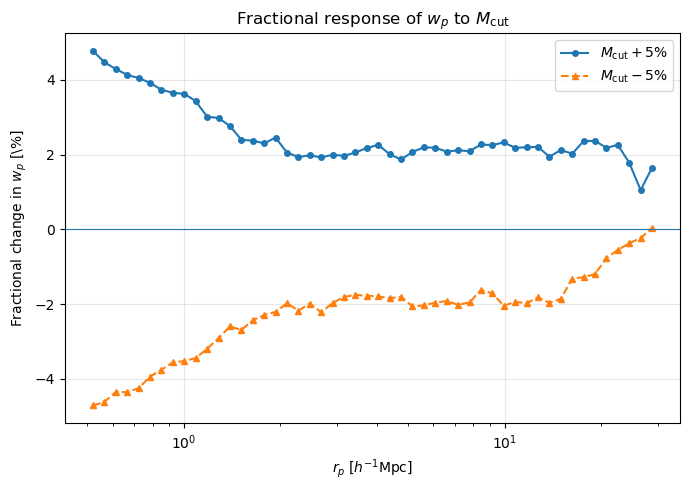

In [20]:
mcut_plus = np.load(Path(DERIVATIVES_DIR) / "Mcut_plus5.npz")
mcut_minus = np.load(Path(DERIVATIVES_DIR) / "Mcut_minus5.npz")

frac_plus = (mcut_plus["wp"] - wp_fid) / wp_fid
frac_minus = (mcut_minus["wp"] - wp_fid) / wp_fid

plt.figure(figsize=(7, 5))

plt.plot(rp, frac_plus * 100, 'o-', ms=4, lw=1.5,
         label=r'$M_{\rm cut}+5\%$')
plt.plot(rp, frac_minus * 100, '^--', ms=4, lw=1.5,
         label=r'$M_{\rm cut}-5\%$')

plt.xscale('log')
plt.axhline(0, lw=0.8)

plt.xlabel(r'$r_p\;[h^{-1}\mathrm{Mpc}]$')
plt.ylabel(r'Fractional change in $w_p$ [\%]')
plt.title(r'Fractional response of $w_p$ to $M_{\rm cut}$')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

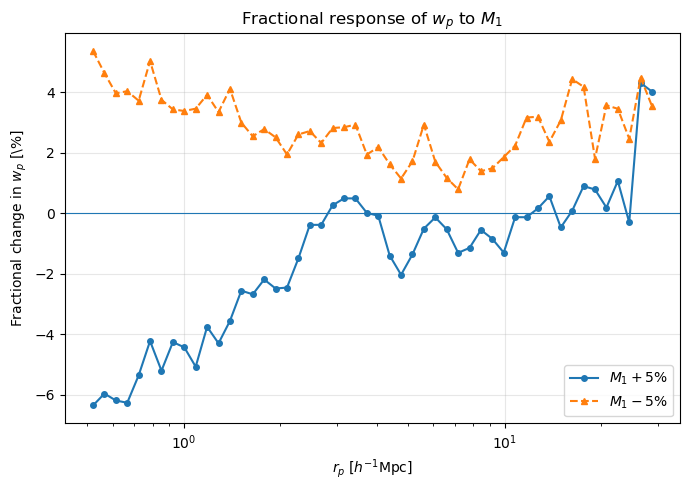

In [21]:
m1_plus = np.load(Path(DERIVATIVES_DIR) / "M1_plus5.npz")
m1_minus = np.load(Path(DERIVATIVES_DIR) / "M1_minus5.npz")

frac_plus = (m1_plus["wp"] - wp_fid) / wp_fid
frac_minus = (m1_minus["wp"] - wp_fid) / wp_fid

plt.figure(figsize=(7, 5))

plt.plot(rp, frac_plus * 100, 'o-', ms=4, lw=1.5,
         label=r'$M_1+5\%$')
plt.plot(rp, frac_minus * 100, '^--', ms=4, lw=1.5,
         label=r'$M_1-5\%$')

plt.xscale('log')
plt.axhline(0, lw=0.8)

plt.xlabel(r'$r_p\;[h^{-1}\mathrm{Mpc}]$')
plt.ylabel(r'Fractional change in $w_p$ [\%]')
plt.title(r'Fractional response of $w_p$ to $M_1$')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

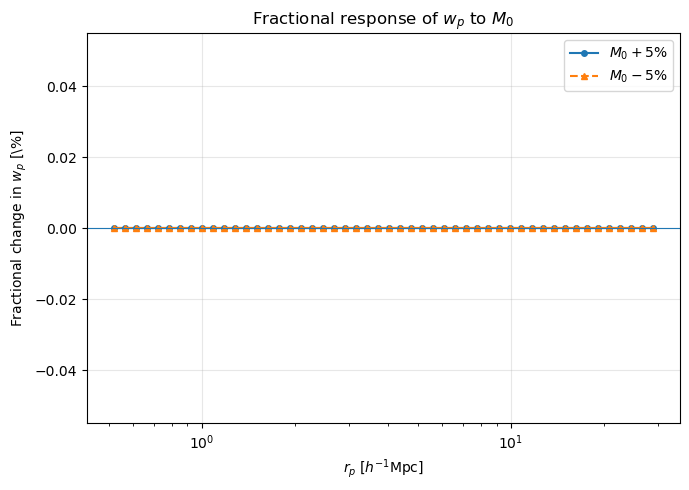

In [22]:
m0_plus = np.load(Path(DERIVATIVES_DIR) / "M0_plus5.npz")
m0_minus = np.load(Path(DERIVATIVES_DIR) / "M0_minus5.npz")

frac_plus = (m0_plus["wp"] - wp_fid) / wp_fid
frac_minus = (m0_minus["wp"] - wp_fid) / wp_fid

plt.figure(figsize=(7, 5))

plt.plot(rp, frac_plus * 100, 'o-', ms=4, lw=1.5,
         label=r'$M_0+5\%$')
plt.plot(rp, frac_minus * 100, '^--', ms=4, lw=1.5,
         label=r'$M_0-5\%$')

plt.xscale('log')
plt.axhline(0, lw=0.8)

plt.xlabel(r'$r_p\;[h^{-1}\mathrm{Mpc}]$')
plt.ylabel(r'Fractional change in $w_p$ [\%]')
plt.title(r'Fractional response of $w_p$ to $M_0$')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

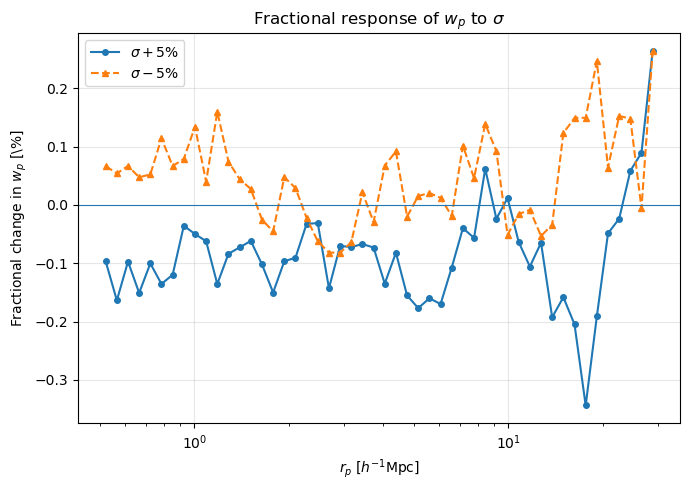

In [23]:
sigma_plus = np.load(Path(DERIVATIVES_DIR) / "sigma_plus5.npz")
sigma_minus = np.load(Path(DERIVATIVES_DIR) / "sigma_minus5.npz")

frac_plus = (sigma_plus["wp"] - wp_fid) / wp_fid
frac_minus = (sigma_minus["wp"] - wp_fid) / wp_fid

plt.figure(figsize=(7, 5))

plt.plot(rp, frac_plus * 100, 'o-', ms=4, lw=1.5,
         label=r'$\sigma+5\%$')
plt.plot(rp, frac_minus * 100, '^--', ms=4, lw=1.5,
         label=r'$\sigma-5\%$')

plt.xscale('log')
plt.axhline(0, lw=0.8)

plt.xlabel(r'$r_p\;[h^{-1}\mathrm{Mpc}]$')
plt.ylabel(r'Fractional change in $w_p$ [\%]')
plt.title(r'Fractional response of $w_p$ to $\sigma$')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

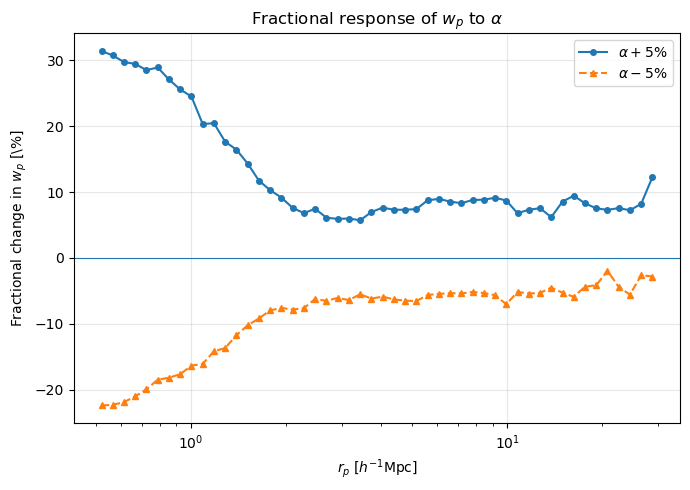

In [24]:
alpha_plus = np.load(Path(DERIVATIVES_DIR) / "alpha_plus5.npz")
alpha_minus = np.load(Path(DERIVATIVES_DIR) / "alpha_minus5.npz")

frac_plus = (alpha_plus["wp"] - wp_fid) / wp_fid
frac_minus = (alpha_minus["wp"] - wp_fid) / wp_fid

plt.figure(figsize=(7, 5))

plt.plot(rp, frac_plus * 100, 'o-', ms=4, lw=1.5,
         label=r'$\alpha+5\%$')
plt.plot(rp, frac_minus * 100, '^--', ms=4, lw=1.5,
         label=r'$\alpha-5\%$')

plt.xscale('log')
plt.axhline(0, lw=0.8)

plt.xlabel(r'$r_p\;[h^{-1}\mathrm{Mpc}]$')
plt.ylabel(r'Fractional change in $w_p$ [\%]')
plt.title(r'Fractional response of $w_p$ to $\alpha$')

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
def plot_fractional_response(param, delta_tag="2p5"):

    delta = 0.025 if delta_tag == "2p5" else 0.050

    tag = "2p5" if delta_tag == "2p5" else "5"

    plus_file = Path(DERIVATIVES_DIR) / f"{param}_plus{tag}.npz"
    minus_file = Path(DERIVATIVES_DIR) / f"{param}_minus{tag}.npz"

    plus = np.load(plus_file)
    minus = np.load(minus_file)

    frac_plus = (plus["wp"] - wp_fid) / wp_fid
    frac_minus = (minus["wp"] - wp_fid) / wp_fid

    plt.figure(figsize=(7, 5))

    plt.plot(
        rp, frac_plus * 100,
        'o-', ms=4, lw=1.5,
        label=fr'${param} + {delta*100:.1f}\%$'
    )

    plt.plot(
        rp, frac_minus * 100,
        '^--', ms=4, lw=1.5,
        label=fr'${param} - {delta*100:.1f}\%$'
    )

    plt.xscale('log')
    plt.axhline(0, lw=0.8)

    plt.xlabel(r'$r_p\;[h^{-1}\mathrm{Mpc}]$')
    plt.ylabel(r'Fractional change in $w_p$ [\%]')
    plt.title(fr'Fractional response of $w_p$ to ${param}$')

    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

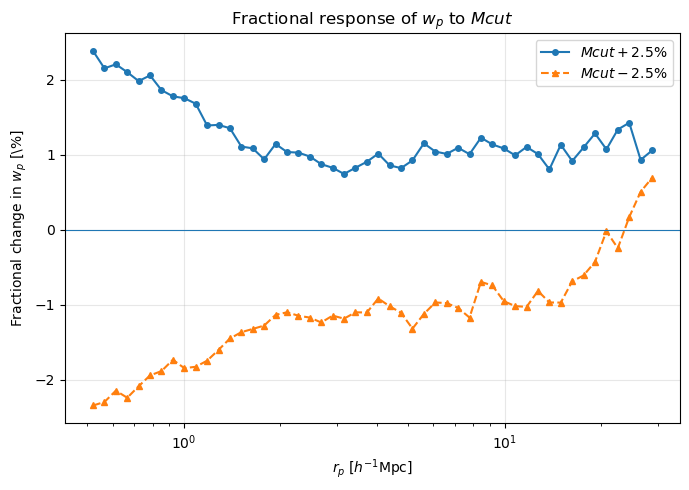

In [26]:
plot_fractional_response("Mcut", "2p5")

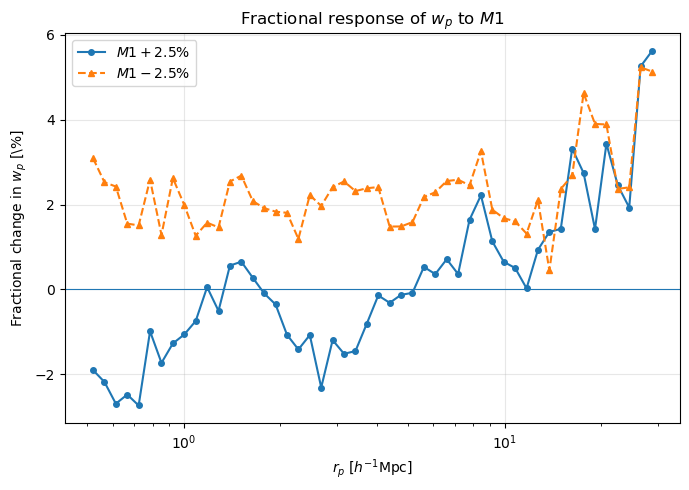

In [27]:
plot_fractional_response("M1", "2p5")

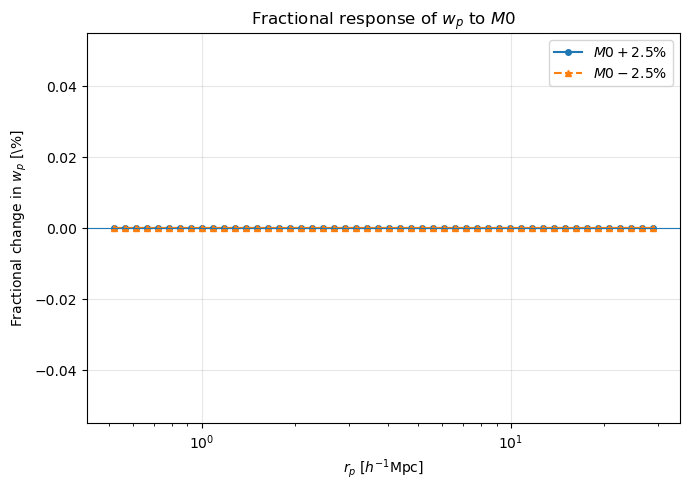

In [28]:
plot_fractional_response("M0", "2p5")

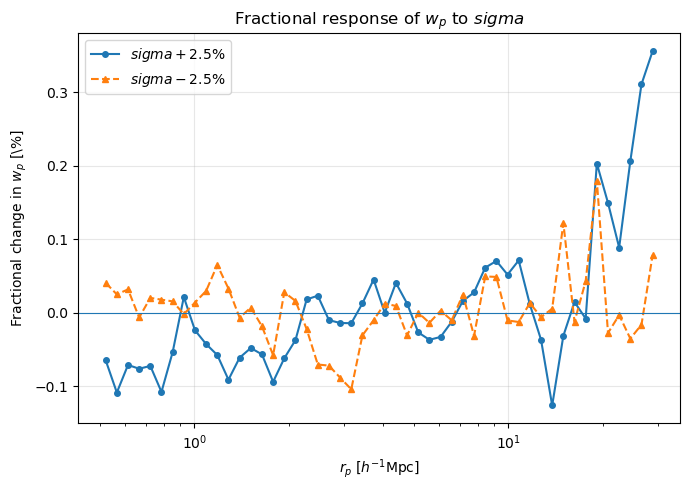

In [29]:
plot_fractional_response("sigma", "2p5")

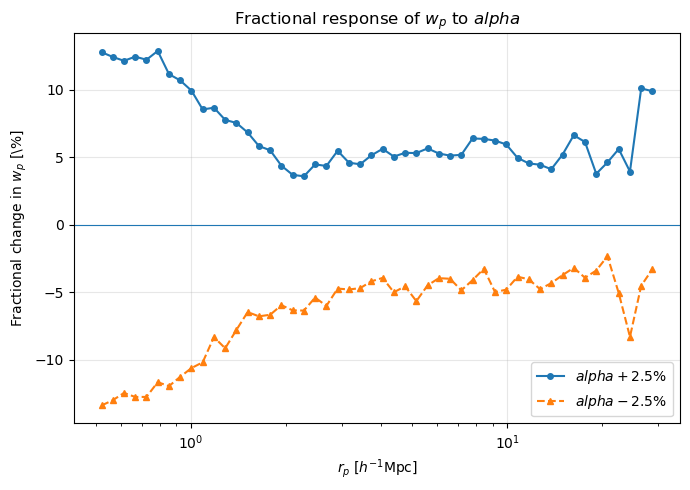

In [30]:
plot_fractional_response("alpha", "2p5")

In [31]:
# Jackknife data already loaded above:
# rp_jk, wp_mean, cov, diag_err

print("Jackknife analysis")
print("=" * 60)

print(f"Number of rp bins       : {len(rp_jk)}")
print(f"Covariance shape        : {cov.shape}")
print(f"Error vector shape      : {diag_err.shape}")

print(f"\nrp range                : "
      f"{rp_jk.min():.3f} - {rp_jk.max():.3f} h^-1 Mpc")

print(f"wp_mean range           : "
      f"{wp_mean.min():.3f} - {wp_mean.max():.3f}")

print(f"Error range             : "
      f"{diag_err.min():.3e} - {diag_err.max():.3e}")

print("\nBasic checks")
print("-" * 60)
print(f"Covariance symmetric    : {np.allclose(cov, cov.T)}")
print(f"Covariance finite       : {np.all(np.isfinite(cov))}")
print(f"Diagonal positive       : {np.all(np.diag(cov) > 0)}")
print(f"diag_err correct        : {np.allclose(diag_err, np.sqrt(np.diag(cov)))}")

Jackknife analysis
Number of rp bins       : 50
Covariance shape        : (50, 50)
Error vector shape      : (50,)

rp range                : 0.521 - 28.837 h^-1 Mpc
wp_mean range           : 1.646 - 140.289
Error range             : 1.374e+00 - 8.688e+00

Basic checks
------------------------------------------------------------
Covariance symmetric    : True
Covariance finite       : True
Diagonal positive       : True
diag_err correct        : True


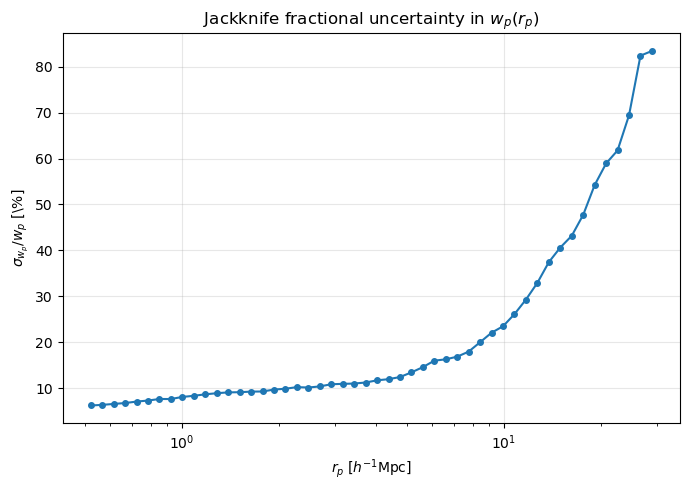

In [32]:
fractional_error = diag_err / wp_mean

plt.figure(figsize=(7, 5))

plt.plot(
    rp_jk,
    fractional_error * 100,
    'o-',
    ms=4,
    lw=1.5
)

plt.xscale('log')

plt.xlabel(r'$r_p\;[h^{-1}\mathrm{Mpc}]$')
plt.ylabel(r'$\sigma_{w_p}/w_p$ [\%]')
plt.title(r'Jackknife fractional uncertainty in $w_p(r_p)$')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

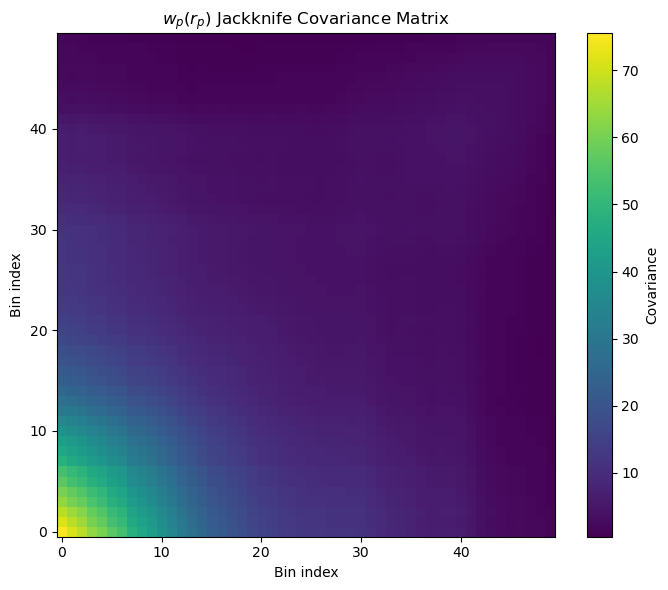

In [33]:
plt.figure(figsize=(7, 6))

plt.imshow(
    cov,
    origin='lower',
    aspect='auto'
)

plt.colorbar(label=r'Covariance')

plt.xlabel('Bin index')
plt.ylabel('Bin index')
plt.title(r'$w_p(r_p)$ Jackknife Covariance Matrix')

plt.tight_layout()
plt.show()

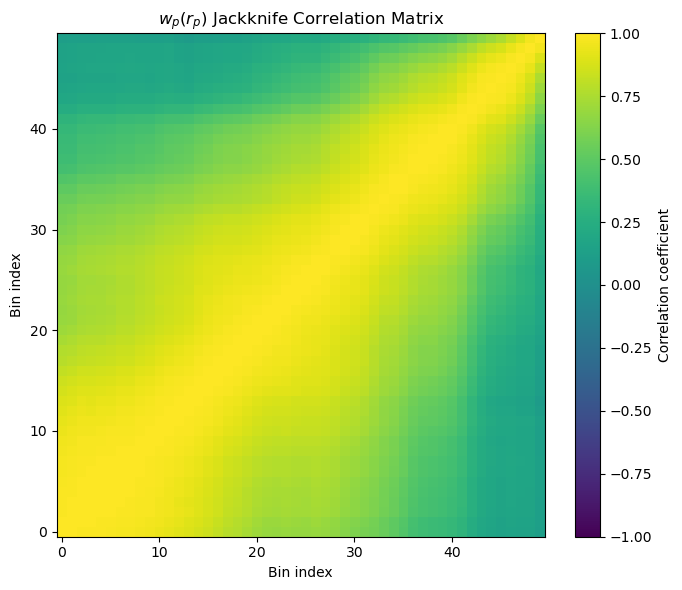

In [34]:
corr = cov / np.sqrt(
    np.outer(np.diag(cov), np.diag(cov))
)

plt.figure(figsize=(7, 6))

plt.imshow(
    corr,
    origin='lower',
    aspect='auto',
    vmin=-1,
    vmax=1
)

plt.colorbar(label=r'Correlation coefficient')

plt.xlabel('Bin index')
plt.ylabel('Bin index')
plt.title(r'$w_p(r_p)$ Jackknife Correlation Matrix')

plt.tight_layout()
plt.show()

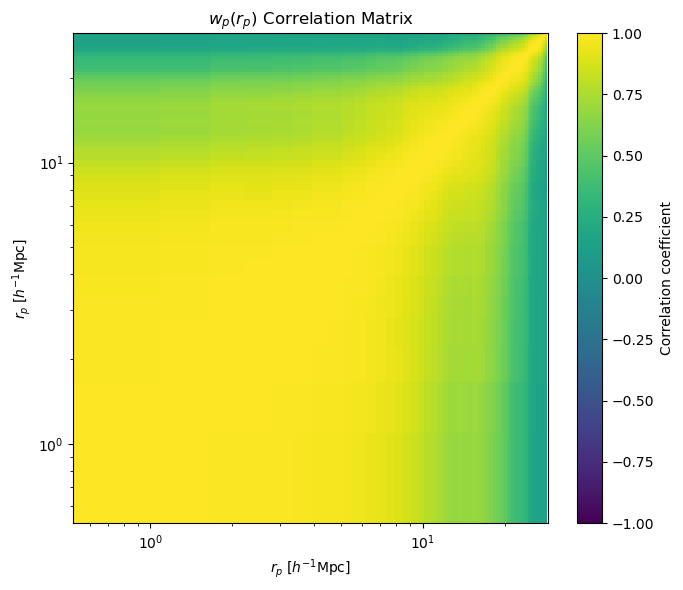

In [35]:
plt.figure(figsize=(7, 6))

extent = [
    rp_jk.min(),
    rp_jk.max(),
    rp_jk.min(),
    rp_jk.max()
]

plt.imshow(
    corr,
    origin='lower',
    aspect='auto',
    extent=extent,
    vmin=-1,
    vmax=1
)

plt.colorbar(label=r'Correlation coefficient')

plt.xscale('log')
plt.yscale('log')

plt.xlabel(r'$r_p\;[h^{-1}\mathrm{Mpc}]$')
plt.ylabel(r'$r_p\;[h^{-1}\mathrm{Mpc}]$')
plt.title(r'$w_p(r_p)$ Correlation Matrix')

plt.tight_layout()
plt.show()

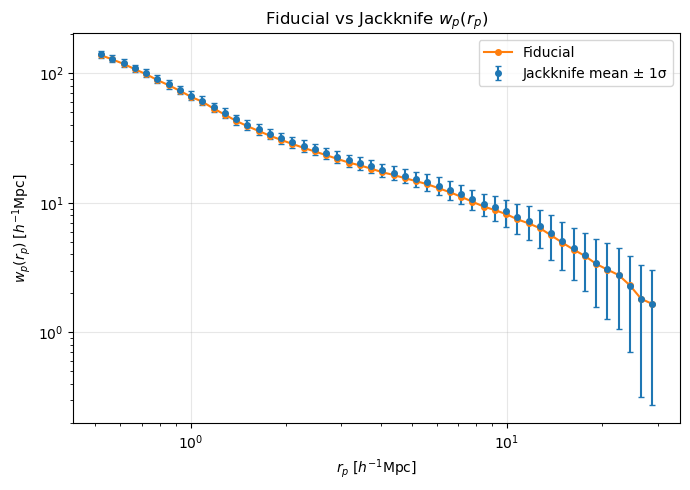

In [36]:
# Jackknife error analysis

fig, ax = plt.subplots(figsize=(7, 5))

ax.errorbar(
    rp_jk,
    wp_mean,
    yerr=diag_err,
    fmt='o',
    ms=4,
    capsize=2,
    label='Jackknife mean ± 1σ'
)

ax.plot(
    rp,
    wp_fid,
    'o-',
    ms=4,
    lw=1.5,
    label='Fiducial'
)

ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel(r'$r_p\;[h^{-1}\mathrm{Mpc}]$')
ax.set_ylabel(r'$w_p(r_p)\;[h^{-1}\mathrm{Mpc}]$')
ax.set_title(r'Fiducial vs Jackknife $w_p(r_p)$')

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

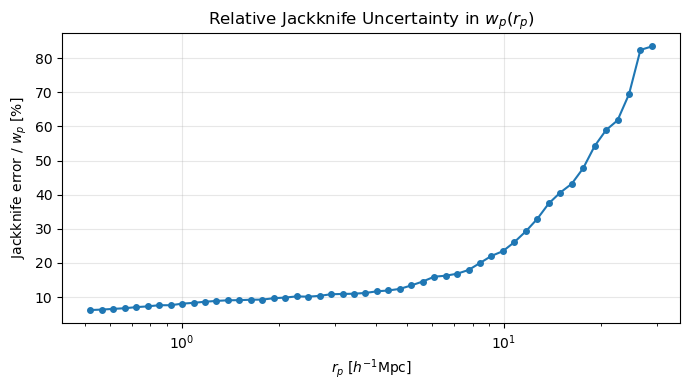

In [37]:
# Relative jackknife uncertainty

frac_err = diag_err / wp_mean

fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(
    rp_jk,
    100 * frac_err,
    'o-',
    ms=4,
    lw=1.5
)

ax.set_xscale('log')

ax.set_xlabel(r'$r_p\;[h^{-1}\mathrm{Mpc}]$')
ax.set_ylabel(r'Jackknife error / $w_p$ [%]')
ax.set_title(r'Relative Jackknife Uncertainty in $w_p(r_p)$')

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

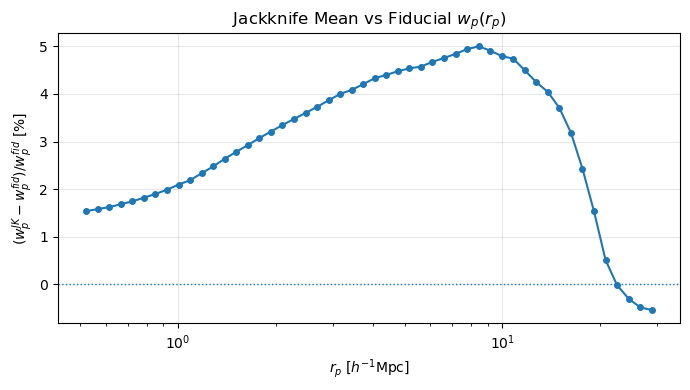

Maximum absolute relative difference: 5.00%


In [38]:
# Fiducial vs jackknife mean: relative difference

relative_difference = (wp_mean - wp_fid) / wp_fid

fig, ax = plt.subplots(figsize=(7, 4))

ax.axhline(0, ls=':', lw=1)

ax.plot(
    rp,
    100 * relative_difference,
    'o-',
    ms=4,
    lw=1.5
)

ax.set_xscale('log')

ax.set_xlabel(r'$r_p\;[h^{-1}\mathrm{Mpc}]$')
ax.set_ylabel(r'$(w_p^{JK}-w_p^{fid})/w_p^{fid}$ [%]')
ax.set_title(r'Jackknife Mean vs Fiducial $w_p(r_p)$')

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(
    f"Maximum absolute relative difference: "
    f"{100*np.max(np.abs(relative_difference)):.2f}%"
)

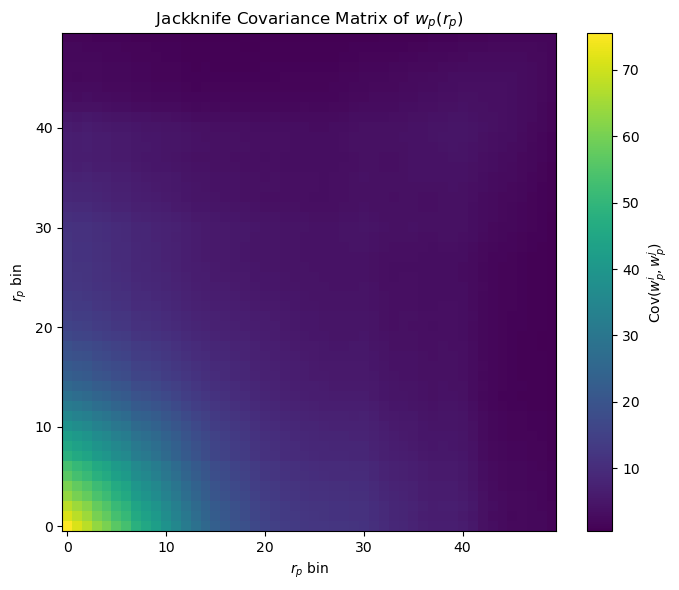

In [39]:
# Covariance matrix

fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(
    cov,
    origin='lower',
    aspect='auto'
)

ax.set_xlabel(r'$r_p$ bin')
ax.set_ylabel(r'$r_p$ bin')
ax.set_title(r'Jackknife Covariance Matrix of $w_p(r_p)$')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r'Cov$(w_p^i,w_p^j)$')

plt.tight_layout()
plt.show()

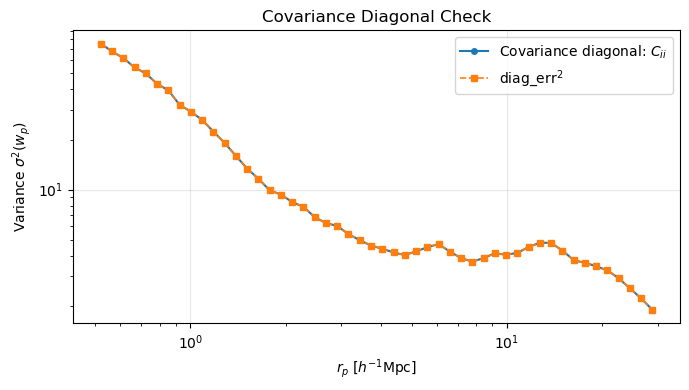

Diagonal consistency:
True


In [40]:
# Covariance diagonal vs jackknife error

cov_diag = np.diag(cov)

fig, ax = plt.subplots(figsize=(7, 4))

ax.loglog(
    rp,
    cov_diag,
    'o-',
    ms=4,
    lw=1.5,
    label=r'Covariance diagonal: $C_{ii}$'
)

ax.loglog(
    rp,
    diag_err**2,
    's--',
    ms=4,
    lw=1.2,
    label=r'$\mathrm{diag\_err}^2$'
)

ax.set_xlabel(r'$r_p\;[h^{-1}\mathrm{Mpc}]$')
ax.set_ylabel(r'Variance $\sigma^2(w_p)$')
ax.set_title(r'Covariance Diagonal Check')

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

print("Diagonal consistency:")
print(np.allclose(cov_diag, diag_err**2))

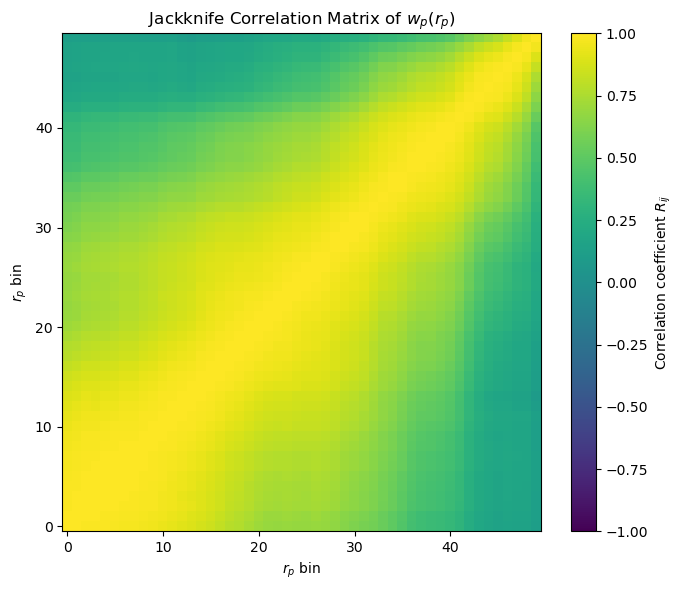

In [41]:
# Correlation matrix

corr = cov / np.sqrt(
    np.outer(
        np.diag(cov),
        np.diag(cov)
    )
)

fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(
    corr,
    origin='lower',
    aspect='auto',
    vmin=-1,
    vmax=1
)

ax.set_xlabel(r'$r_p$ bin')
ax.set_ylabel(r'$r_p$ bin')
ax.set_title(r'Jackknife Correlation Matrix of $w_p(r_p)$')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r'Correlation coefficient $R_{ij}$')

plt.tight_layout()
plt.show()

In [42]:
print("Correlation matrix checks")
print("-" * 50)
print(f"Symmetric : {np.allclose(corr, corr.T)}")
print(f"Finite    : {np.all(np.isfinite(corr))}")
print(f"Diagonal=1: {np.allclose(np.diag(corr), 1.0)}")
print(f"Range     : [{corr.min():.4f}, {corr.max():.4f}]")

Correlation matrix checks
--------------------------------------------------
Symmetric : True
Finite    : True
Diagonal=1: True
Range     : [0.1015, 1.0000]


In [43]:
# ------------------------------------------------------------
# Load jackknife results for all njn values
# ------------------------------------------------------------

from pathlib import Path
import numpy as np

RESULTS_DIR = Path("results")

NJN_VALUES = [64, 100, 144]

jk_data = {}

for njn in NJN_VALUES:
    path = RESULTS_DIR / f"wp_jackknife_njn{njn}.npz"

    if not path.exists():
        print(f"WARNING: file not found -> {path}")
        continue

    data = np.load(path)

    jk_data[njn] = {
        "rp": data["rp"],
        "wp_mean": data["wp_mean"],
        "cov": data["cov"],
        "diag_err": data["diag_err"],
    }

    print(f"Loaded njn={njn}")
    print(f"  file       : {path}")
    print(f"  rp         : {data['rp'].shape}")
    print(f"  wp_mean    : {data['wp_mean'].shape}")
    print(f"  covariance : {data['cov'].shape}")
    print(f"  diag_err   : {data['diag_err'].shape}")

Loaded njn=100
  file       : results/wp_jackknife_njn100.npz
  rp         : (50,)
  wp_mean    : (50,)
  covariance : (50, 50)
  diag_err   : (50,)


In [44]:
# ------------------------------------------------------------
# Inspect available jackknife result files
# ------------------------------------------------------------

from pathlib import Path

results_dir = Path("results")

print("Jackknife files found:")
print("=" * 60)

for path in sorted(results_dir.glob("*jackknife*")):
    print(path.name)

Jackknife files found:
gpos_jackknife_njn100_los1.fits
wp_jackknife_njn100.npz
wp_jackknife_njn100_Mr18_seed10.npz
wp_jackknife_njn144_Mr18_seed10.npz
wp_jackknife_njn64_Mr18_seed10.npz


In [45]:
# ------------------------------------------------------------
# Load wp jackknife results for all njn values
# ------------------------------------------------------------

from pathlib import Path
import numpy as np

results_dir = Path("results")

NJN_VALUES = [64, 100, 144]

wp_jk_all = {}

for njn in NJN_VALUES:
    path = results_dir / f"wp_jackknife_njn{njn}_Mr18_seed10.npz"

    if not path.exists():
        print(f"WARNING: missing {path}")
        continue

    data = np.load(path)

    wp_jk_all[njn] = {
        "rp": data["rp"],
        "wp_mean": data["wp_mean"],
        "cov": data["cov"],
        "diag_err": data["diag_err"],
    }

    print(f"Loaded njn={njn}")
    print(f"  file       : {path}")
    print(f"  rp         : {data['rp'].shape}")
    print(f"  wp_mean    : {data['wp_mean'].shape}")
    print(f"  covariance : {data['cov'].shape}")
    print(f"  diag_err   : {data['diag_err'].shape}")

Loaded njn=64
  file       : results/wp_jackknife_njn64_Mr18_seed10.npz
  rp         : (50,)
  wp_mean    : (50,)
  covariance : (50, 50)
  diag_err   : (50,)
Loaded njn=100
  file       : results/wp_jackknife_njn100_Mr18_seed10.npz
  rp         : (50,)
  wp_mean    : (50,)
  covariance : (50, 50)
  diag_err   : (50,)
Loaded njn=144
  file       : results/wp_jackknife_njn144_Mr18_seed10.npz
  rp         : (50,)
  wp_mean    : (50,)
  covariance : (50, 50)
  diag_err   : (50,)


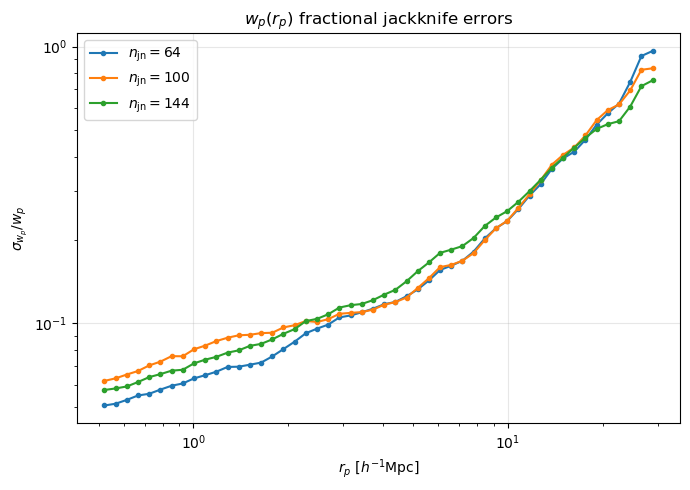

In [46]:
# ------------------------------------------------------------
# Plot fractional jackknife errors
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

for njn in NJN_VALUES:
    if njn not in wp_jk_all:
        continue

    data = wp_jk_all[njn]

    fractional_error = data["diag_err"] / np.abs(data["wp_mean"])

    plt.plot(
        data["rp"],
        fractional_error,
        marker="o",
        ms=3,
        lw=1.5,
        label=fr"$n_{{\rm jn}}={njn}$"
    )

plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"$r_p\ [h^{-1}\mathrm{Mpc}]$")
plt.ylabel(r"$\sigma_{w_p}/w_p$")
plt.title(r"$w_p(r_p)$ fractional jackknife errors")

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

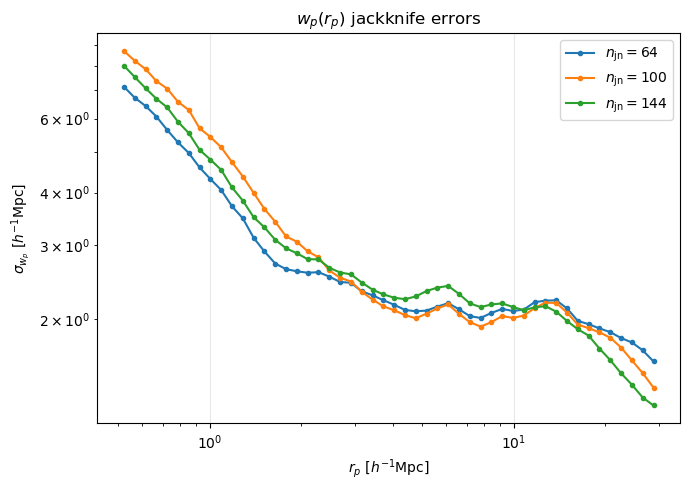

In [47]:
# ------------------------------------------------------------
# Plot absolute jackknife errors
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

for njn in NJN_VALUES:
    if njn not in wp_jk_all:
        continue

    data = wp_jk_all[njn]

    plt.loglog(
        data["rp"],
        data["diag_err"],
        marker="o",
        ms=3,
        lw=1.5,
        label=fr"$n_{{\rm jn}}={njn}$"
    )

plt.xlabel(r"$r_p\ [h^{-1}\mathrm{Mpc}]$")
plt.ylabel(r"$\sigma_{w_p}\ [h^{-1}\mathrm{Mpc}]$")
plt.title(r"$w_p(r_p)$ jackknife errors")

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

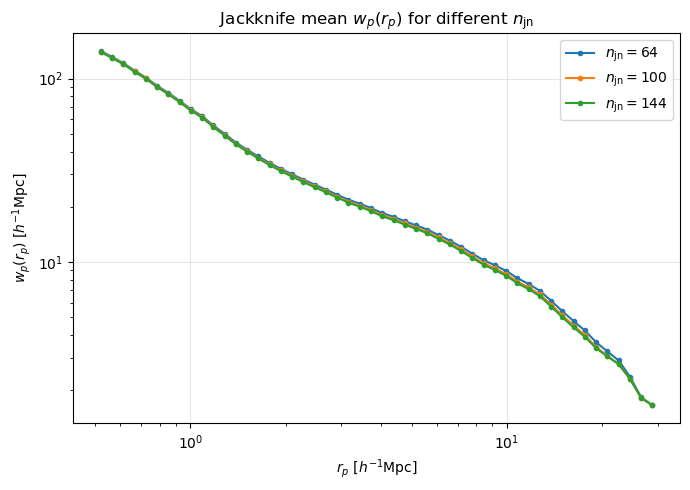

In [48]:
# ------------------------------------------------------------
# Compare jackknife mean wp for different njn
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

for njn in NJN_VALUES:
    if njn not in wp_jk_all:
        continue

    data = wp_jk_all[njn]

    plt.loglog(
        data["rp"],
        data["wp_mean"],
        marker="o",
        ms=3,
        lw=1.5,
        label=fr"$n_{{\rm jn}}={njn}$"
    )

plt.xlabel(r"$r_p\ [h^{-1}\mathrm{Mpc}]$")
plt.ylabel(r"$w_p(r_p)\ [h^{-1}\mathrm{Mpc}]$")
plt.title(r"Jackknife mean $w_p(r_p)$ for different $n_{\rm jn}$")

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [49]:
# ------------------------------------------------------------
# Inspect available quantities in the njn files
# ------------------------------------------------------------

for njn in NJN_VALUES:
    path = results_dir / f"wp_jackknife_njn{njn}_Mr18_seed10.npz"

    data = np.load(path)

    print(f"njn={njn}")
    print("keys:", data.files)
    print()
    

njn=64
keys: ['rp', 'wp_mean', 'cov', 'diag_err', 'njn', 'los', 'Mr_thresh', 'seed', 'rsd']

njn=100
keys: ['rp', 'wp_mean', 'cov', 'diag_err', 'njn', 'los', 'Mr_thresh', 'seed', 'rsd']

njn=144
keys: ['rp', 'wp_mean', 'cov', 'diag_err', 'njn', 'los', 'Mr_thresh', 'seed', 'rsd']



In [50]:
# ------------------------------------------------------------
# Load wp jackknife results for all njn values
# ------------------------------------------------------------

JK_FILES = {
    64: "results/wp_jackknife_njn64_Mr18_seed10.npz",
    100: "results/wp_jackknife_njn100_Mr18_seed10.npz",
    144: "results/wp_jackknife_njn144_Mr18_seed10.npz",
}

jk_data = {}

for njn, filepath in JK_FILES.items():
    data = np.load(filepath)

    jk_data[njn] = {
        "rp": data["rp"],
        "wp_mean": data["wp_mean"],
        "cov": data["cov"],
        "diag_err": data["diag_err"],
    }

    print(f"Loaded njn={njn}")
    print(f"  wp_mean : {data['wp_mean'].shape}")
    print(f"  cov     : {data['cov'].shape}")
    print(f"  errors  : {data['diag_err'].shape}")

Loaded njn=64
  wp_mean : (50,)
  cov     : (50, 50)
  errors  : (50,)
Loaded njn=100
  wp_mean : (50,)
  cov     : (50, 50)
  errors  : (50,)
Loaded njn=144
  wp_mean : (50,)
  cov     : (50, 50)
  errors  : (50,)


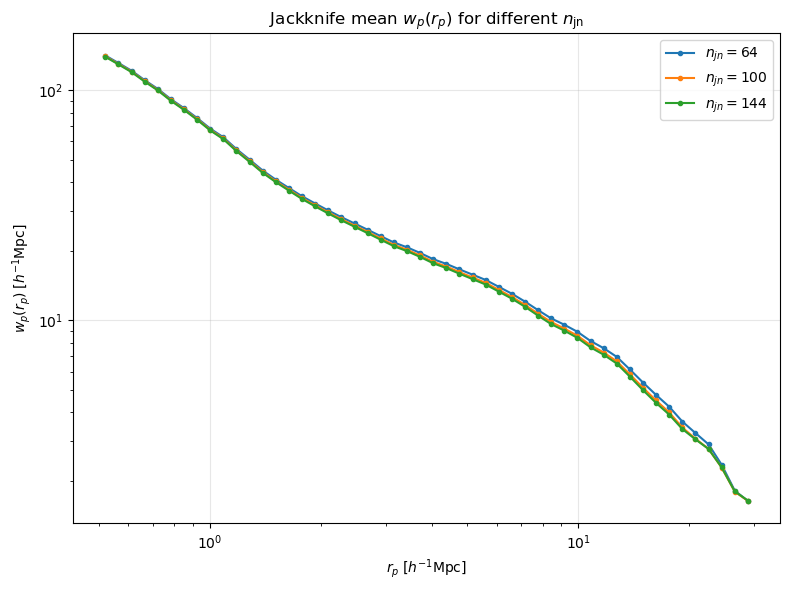

In [51]:
plt.figure(figsize=(8, 6))

for njn in [64, 100, 144]:
    plt.loglog(
        jk_data[njn]["rp"],
        jk_data[njn]["wp_mean"],
        'o-',
        ms=3,
        lw=1.5,
        label=f"$n_{{jn}}={njn}$"
    )

plt.xlabel(r"$r_p\;[h^{-1}\mathrm{Mpc}]$")
plt.ylabel(r"$w_p(r_p)\;[h^{-1}\mathrm{Mpc}]$")
plt.title(r"Jackknife mean $w_p(r_p)$ for different $n_{\rm jn}$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

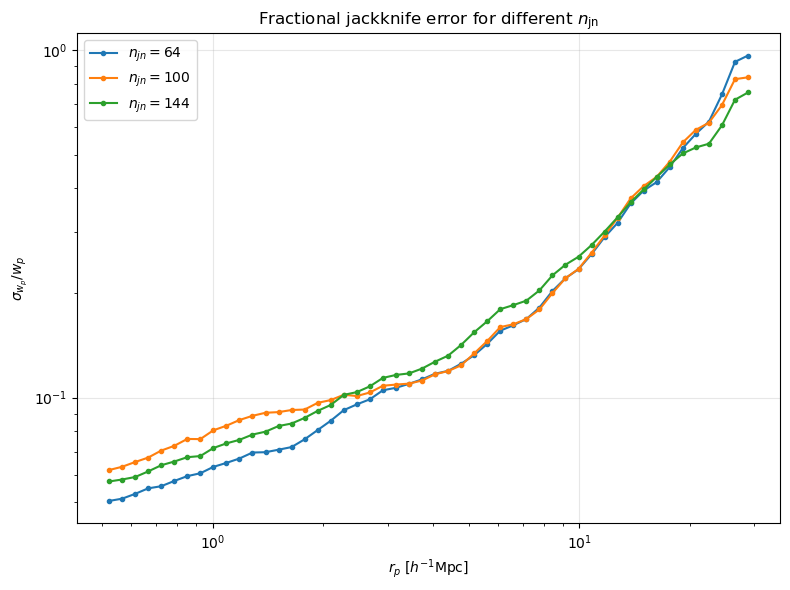

In [52]:
plt.figure(figsize=(8, 6))

for njn in [64, 100, 144]:
    rp_jk = jk_data[njn]["rp"]
    wp_jk = jk_data[njn]["wp_mean"]
    err_jk = jk_data[njn]["diag_err"]

    fractional_error = err_jk / wp_jk

    plt.loglog(
        rp_jk,
        fractional_error,
        'o-',
        ms=3,
        lw=1.5,
        label=f"$n_{{jn}}={njn}$"
    )

plt.xlabel(r"$r_p\;[h^{-1}\mathrm{Mpc}]$")
plt.ylabel(r"$\sigma_{w_p}/w_p$")
plt.title(r"Fractional jackknife error for different $n_{\rm jn}$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

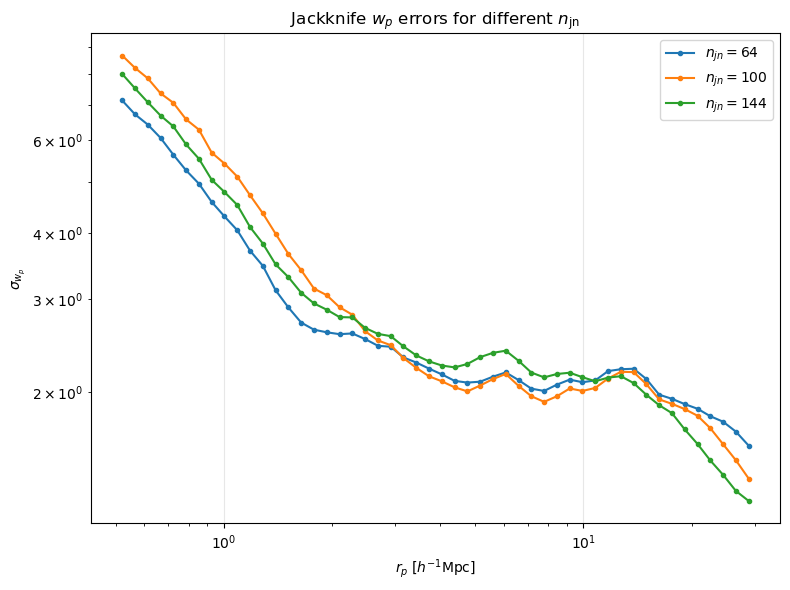

In [53]:
plt.figure(figsize=(8, 6))

for njn in [64, 100, 144]:
    plt.loglog(
        jk_data[njn]["rp"],
        jk_data[njn]["diag_err"],
        'o-',
        ms=3,
        lw=1.5,
        label=f"$n_{{jn}}={njn}$"
    )

plt.xlabel(r"$r_p\;[h^{-1}\mathrm{Mpc}]$")
plt.ylabel(r"$\sigma_{w_p}$")
plt.title(r"Jackknife $w_p$ errors for different $n_{\rm jn}$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

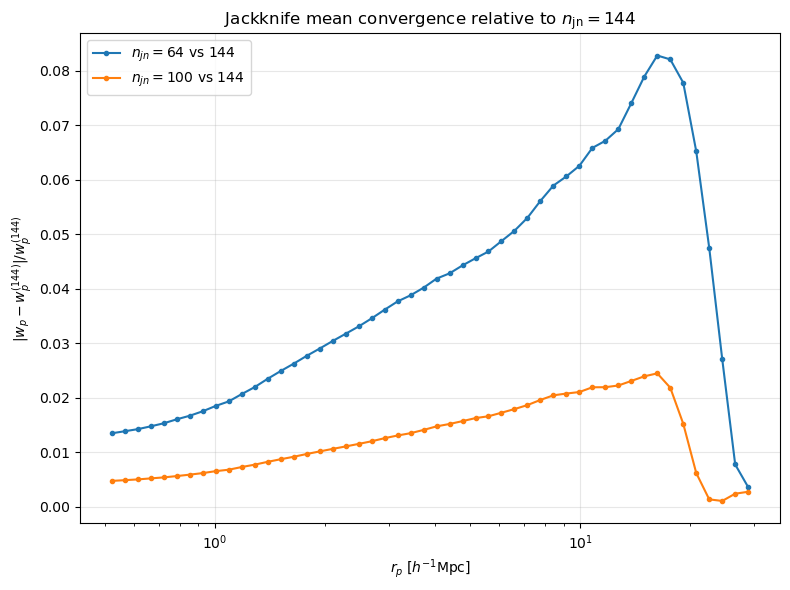

In [54]:
wp_144 = jk_data[144]["wp_mean"]
rp_144 = jk_data[144]["rp"]

plt.figure(figsize=(8, 6))

for njn in [64, 100]:
    wp = jk_data[njn]["wp_mean"]

    relative_difference = np.abs(wp - wp_144) / np.abs(wp_144)

    plt.semilogx(
        rp_144,
        relative_difference,
        'o-',
        ms=3,
        lw=1.5,
        label=fr"$n_{{jn}}={njn}$ vs $144$"
    )

plt.xlabel(r"$r_p\;[h^{-1}\mathrm{Mpc}]$")
plt.ylabel(r"$|w_p-w_p^{(144)}|/w_p^{(144)}$")
plt.title(r"Jackknife mean convergence relative to $n_{\rm jn}=144$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [55]:
print("Mean wp convergence relative to njn=144")
print("=" * 60)

wp_ref = jk_data[144]["wp_mean"]

for njn in [64, 100]:
    wp = jk_data[njn]["wp_mean"]

    rel_diff = np.abs(wp - wp_ref) / np.abs(wp_ref)

    print(f"\nnjn = {njn}")
    print(f"  median relative difference : {np.median(rel_diff):.4%}")
    print(f"  mean relative difference   : {np.mean(rel_diff):.4%}"
         )
    print(f"  maximum relative difference: {np.max(rel_diff):.4%}")

Mean wp convergence relative to njn=144

njn = 64
  median relative difference : 3.6945%
  mean relative difference   : 3.9580%
  maximum relative difference: 8.2814%

njn = 100
  median relative difference : 1.1811%
  mean relative difference   : 1.2406%
  maximum relative difference: 2.4510%


In [56]:
print("Fractional error comparison")
print("=" * 60)

for njn in [64, 100, 144]:
    wp = jk_data[njn]["wp_mean"]
    err = jk_data[njn]["diag_err"]

    frac_err = err / wp

    print(f"\nnjn = {njn}")
    print(f"  median fractional error : {np.median(frac_err):.4%}")
    print(f"  mean fractional error   : {np.mean(frac_err):.4%}")
    print(f"  minimum                 : {np.min(frac_err):.4%}")
    print(f"  maximum                 : {np.max(frac_err):.4%}")

Fractional error comparison

njn = 64
  median fractional error : 11.5074%
  mean fractional error   : 21.3970%
  minimum                 : 5.0470%
  maximum                 : 96.4152%

njn = 100
  median fractional error : 11.4395%
  mean fractional error   : 21.6786%
  minimum                 : 6.1931%
  maximum                 : 83.4581%

njn = 144
  median fractional error : 12.4094%
  mean fractional error   : 21.0367%
  minimum                 : 5.7414%
  maximum                 : 75.4852%


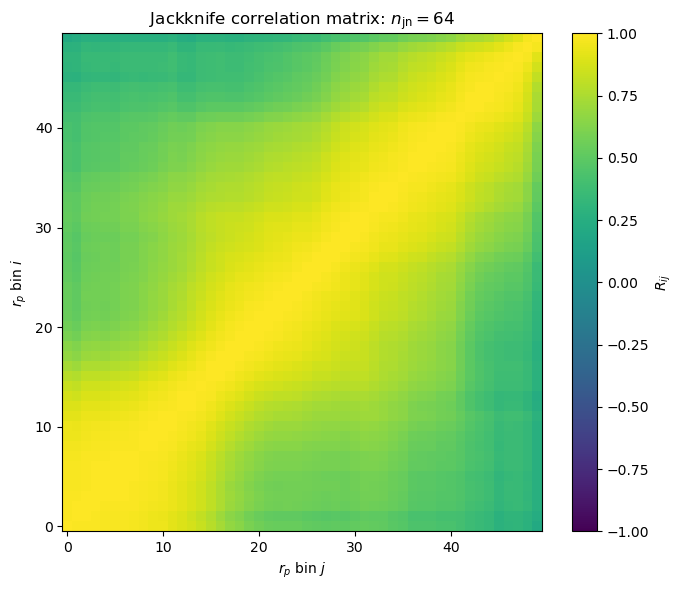

In [57]:
corr_64 = jk_data[64]["cov"] / np.sqrt(
    np.outer(
        np.diag(jk_data[64]["cov"]),
        np.diag(jk_data[64]["cov"])
    )
)

plt.figure(figsize=(7, 6))
plt.imshow(corr_64, origin="lower", aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label=r"$R_{ij}$")
plt.xlabel(r"$r_p$ bin $j$")
plt.ylabel(r"$r_p$ bin $i$")
plt.title(r"Jackknife correlation matrix: $n_{\rm jn}=64$")
plt.tight_layout()
plt.show()

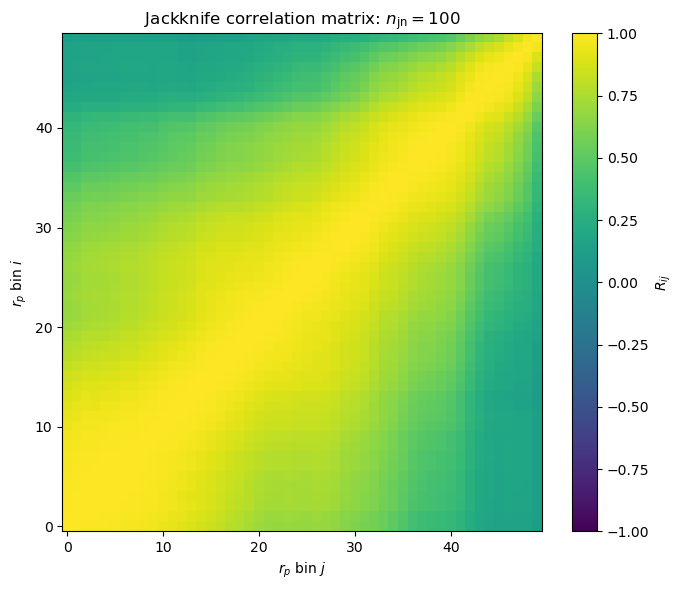

In [58]:
corr_100 = jk_data[100]["cov"] / np.sqrt(
    np.outer(
        np.diag(jk_data[100]["cov"]),
        np.diag(jk_data[100]["cov"])
    )
)

plt.figure(figsize=(7, 6))
plt.imshow(corr_100, origin="lower", aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label=r"$R_{ij}$")
plt.xlabel(r"$r_p$ bin $j$")
plt.ylabel(r"$r_p$ bin $i$")
plt.title(r"Jackknife correlation matrix: $n_{\rm jn}=100$")
plt.tight_layout()
plt.show()

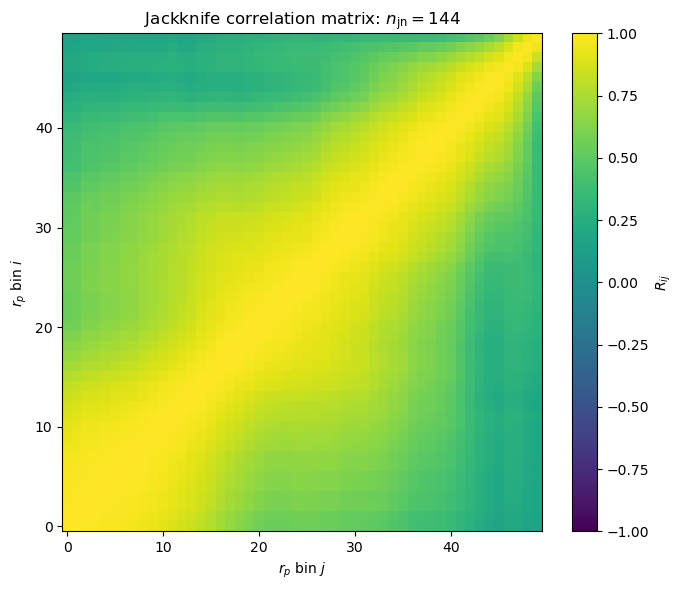

In [59]:
corr_144 = jk_data[144]["cov"] / np.sqrt(
    np.outer(
        np.diag(jk_data[144]["cov"]),
        np.diag(jk_data[144]["cov"])
    )
)

plt.figure(figsize=(7, 6))
plt.imshow(corr_144, origin="lower", aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label=r"$R_{ij}$")
plt.xlabel(r"$r_p$ bin $j$")
plt.ylabel(r"$r_p$ bin $i$")
plt.title(r"Jackknife correlation matrix: $n_{\rm jn}=144$")
plt.tight_layout()
plt.show()

In [60]:
# ------------------------------------------------------------
# Find jackknife galaxy catalogues
# ------------------------------------------------------------

from pathlib import Path

results_dir = Path("results")

for path in sorted(results_dir.glob("*.fits")):
    print(path.name)

centrals.fits
gpos_jackknife_njn100_los1.fits
satellites.fits


Columns:
['x', 'y', 'z', 'jn_region']

Using region column: jn_region

Number of regions: 100
Total galaxies:    292,592
Mean galaxies/region: 2,925.92
Min galaxies/region : 1,673
Max galaxies/region : 6,239
Std galaxies/region:  655.61
Fractional scatter :   22.4068%


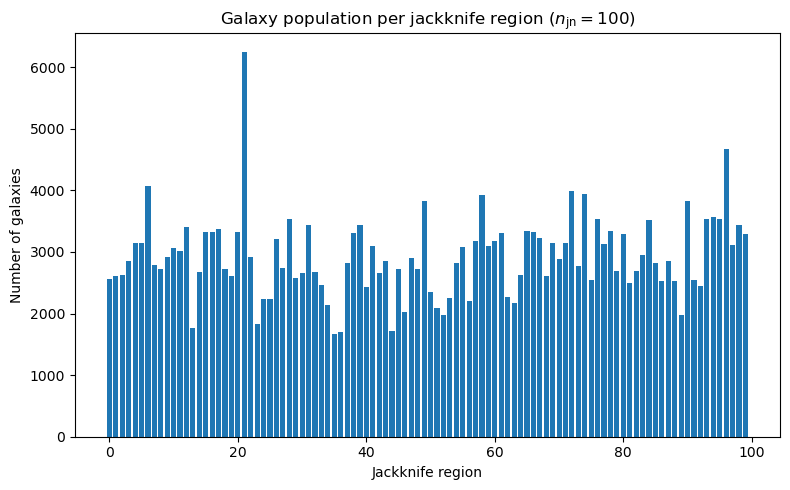

In [61]:
# ------------------------------------------------------------
# Galaxy population in each jackknife region
# ------------------------------------------------------------

from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt

jk_fits = "results/gpos_jackknife_njn100_los1.fits"

with fits.open(jk_fits) as hdul:
    data = hdul[1].data
    print("Columns:")
    print(data.columns.names)

# Find the jackknife region column
region_col = None
for name in data.columns.names:
    if "jk" in name.lower() or "region" in name.lower():
        region_col = name
        break

print(f"\nUsing region column: {region_col}")

regions = np.asarray(data[region_col])

unique_regions, counts = np.unique(regions, return_counts=True)

print(f"\nNumber of regions: {len(unique_regions)}")
print(f"Total galaxies:    {len(regions):,}")
print(f"Mean galaxies/region: {np.mean(counts):,.2f}")
print(f"Min galaxies/region : {np.min(counts):,}")
print(f"Max galaxies/region : {np.max(counts):,}")
print(f"Std galaxies/region:  {np.std(counts):,.2f}")
print(f"Fractional scatter :   {np.std(counts)/np.mean(counts):.4%}")

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.bar(unique_regions, counts)

plt.xlabel("Jackknife region")
plt.ylabel("Number of galaxies")
plt.title(r"Galaxy population per jackknife region ($n_{\rm jn}=100$)")

plt.tight_layout()
plt.show()

In [62]:
# ------------------------------------------------------------
# Load jackknife results for njn = 64, 100, 144
# ------------------------------------------------------------

from pathlib import Path
import numpy as np

JK_FILES = {
    64: Path("results/wp_jackknife_njn64_Mr18_seed10.npz"),
    100: Path("results/wp_jackknife_njn100_Mr18_seed10.npz"),
    144: Path("results/wp_jackknife_njn144_Mr18_seed10.npz"),
}

jk_results = {}

for njn, path in JK_FILES.items():
    data = np.load(path)

    jk_results[njn] = {
        "rp": data["rp"],
        "wp_mean": data["wp_mean"],
        "cov": data["cov"],
        "diag_err": data["diag_err"],
    }

    print(f"njn={njn}")
    print(f"  rp       : {data['rp'].shape}")
    print(f"  wp_mean  : {data['wp_mean'].shape}")
    print(f"  cov      : {data['cov'].shape}")
    print(f"  diag_err : {data['diag_err'].shape}")
    print()

njn=64
  rp       : (50,)
  wp_mean  : (50,)
  cov      : (50, 50)
  diag_err : (50,)

njn=100
  rp       : (50,)
  wp_mean  : (50,)
  cov      : (50, 50)
  diag_err : (50,)

njn=144
  rp       : (50,)
  wp_mean  : (50,)
  cov      : (50, 50)
  diag_err : (50,)



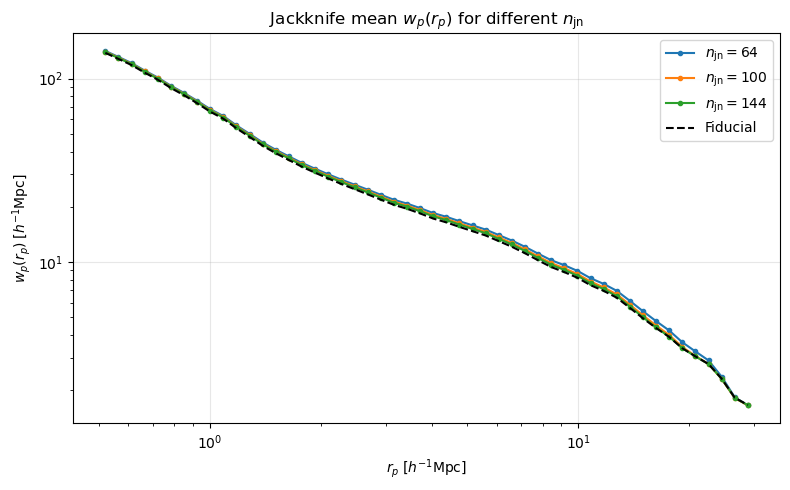

In [63]:
# ------------------------------------------------------------
# Mean wp comparison
# ------------------------------------------------------------

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

for njn in [64, 100, 144]:
    plt.loglog(
        jk_results[njn]["rp"],
        jk_results[njn]["wp_mean"],
        marker="o",
        ms=3,
        lw=1.5,
        label=fr"$n_{{\rm jn}}={njn}$"
    )

plt.loglog(
    rp,
    wp_fid,
    "k--",
    lw=1.5,
    label="Fiducial"
)

plt.xlabel(r"$r_p\;[h^{-1}\mathrm{Mpc}]$")
plt.ylabel(r"$w_p(r_p)\;[h^{-1}\mathrm{Mpc}]$")
plt.title(r"Jackknife mean $w_p(r_p)$ for different $n_{\rm jn}$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

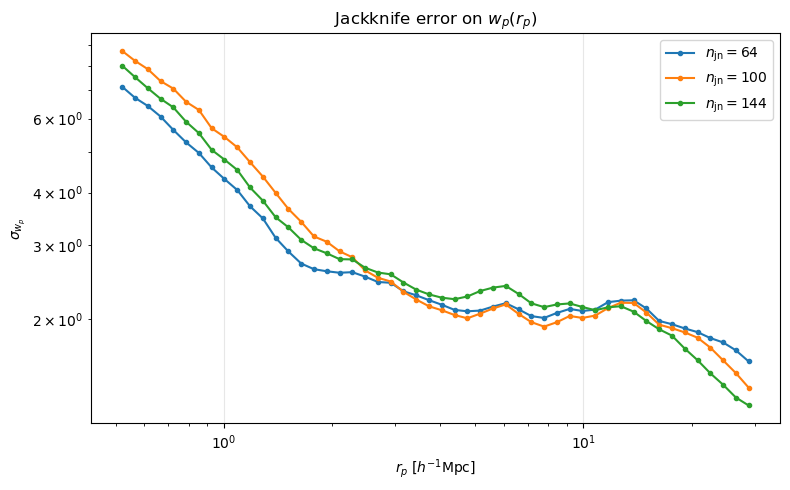

In [64]:
# ------------------------------------------------------------
# Absolute jackknife error comparison
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

for njn in [64, 100, 144]:
    plt.loglog(
        jk_results[njn]["rp"],
        jk_results[njn]["diag_err"],
        marker="o",
        ms=3,
        lw=1.5,
        label=fr"$n_{{\rm jn}}={njn}$"
    )

plt.xlabel(r"$r_p\;[h^{-1}\mathrm{Mpc}]$")
plt.ylabel(r"$\sigma_{w_p}$")
plt.title(r"Jackknife error on $w_p(r_p)$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

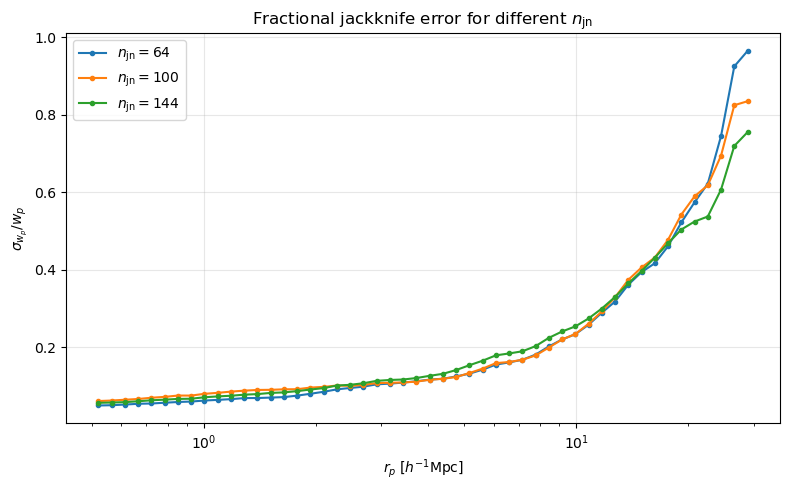

In [65]:
# ------------------------------------------------------------
# Fractional jackknife error
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

for njn in [64, 100, 144]:
    rp_i = jk_results[njn]["rp"]
    wp_i = jk_results[njn]["wp_mean"]
    err_i = jk_results[njn]["diag_err"]

    frac_err = err_i / wp_i

    plt.semilogx(
        rp_i,
        frac_err,
        marker="o",
        ms=3,
        lw=1.5,
        label=fr"$n_{{\rm jn}}={njn}$"
    )

plt.xlabel(r"$r_p\;[h^{-1}\mathrm{Mpc}]$")
plt.ylabel(r"$\sigma_{w_p}/w_p$")
plt.title(r"Fractional jackknife error for different $n_{\rm jn}$")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [67]:
# ------------------------------------------------------------
# Inspect all .npz contents
# ------------------------------------------------------------

from pathlib import Path
import numpy as np

npz_files = sorted(Path("results").glob("*.npz"))

for path in npz_files:
    print("=" * 70)
    print(path)
    print("=" * 70)

    data = np.load(path, allow_pickle=True)

    for key in data.files:
        arr = data[key]

        if np.isscalar(arr) or np.ndim(arr) == 0:
            print(f"{key:<20} scalar : {arr}")
        else:
            print(
                f"{key:<20} "
                f"shape={str(arr.shape):<12} "
                f"dtype={arr.dtype}"
            )

    print()

results/wp_fiducial.npz
rp                   shape=(50,)        dtype=float64
wp                   shape=(50,)        dtype=float64

results/wp_jackknife_njn100.npz
rp                   shape=(50,)        dtype=float64
wp_mean              shape=(50,)        dtype=float64
cov                  shape=(50, 50)     dtype=float64
diag_err             shape=(50,)        dtype=float64
njn                  scalar : 100
los                  scalar : 1
Mr_thresh            scalar : -18.0
seed                 scalar : 10
rsd                  scalar : True

results/wp_jackknife_njn100_Mr18_seed10.npz
rp                   shape=(50,)        dtype=float64
wp_mean              shape=(50,)        dtype=float64
cov                  shape=(50, 50)     dtype=float64
diag_err             shape=(50,)        dtype=float64
njn                  scalar : 100
los                  scalar : 1
Mr_thresh            scalar : -18.0
seed                 scalar : 10
rsd                  scalar : True

results/wp_jackkn

In [68]:
# ------------------------------------------------------------
# Inspect jackknife FITS catalogue
# ------------------------------------------------------------

from astropy.io import fits

fits_path = "results/gpos_jackknife_njn100_los1.fits"

with fits.open(fits_path) as hdul:

    print("HDU structure:")
    hdul.info()

    table = hdul[1].data

    print("\nColumns:")
    for name in table.columns.names:
        print(
            f"{name:<20} "
            f"dtype={table[name].dtype} "
            f"shape={table[name].shape}"
        )

    print("\nFirst 5 rows:")
    print(table[:5])

HDU structure:
Filename: results/gpos_jackknife_njn100_los1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     16   292592R x 4C   [D, D, D, K]   

Columns:
x                    dtype=>f8 shape=(292592,)
y                    dtype=>f8 shape=(292592,)
z                    dtype=>f8 shape=(292592,)
jn_region            dtype=>i8 shape=(292592,)

First 5 rows:
[(32.5881 , 17.907  , 37.17743016, 10)
 (31.80842, 35.39796, 31.41961627, 11)
 (33.88167, 35.69714, 35.48018458, 11)
 (30.49884, 27.40089, 28.96565049, 11)
 (10.56391, 19.41907,  2.05971052,  0)]


In [69]:
# ------------------------------------------------------------
# Jackknife region population statistics
# ------------------------------------------------------------

regions = np.asarray(table["jn_region"])

unique_regions, counts = np.unique(
    regions,
    return_counts=True
)

print("Jackknife region statistics")
print("=" * 60)

print(f"Number of regions : {len(unique_regions)}")
print(f"Total galaxies    : {len(regions):,}")
print(f"Mean per region   : {np.mean(counts):,.2f}")
print(f"Median per region : {np.median(counts):,.2f}")
print(f"Minimum           : {np.min(counts):,}")
print(f"Maximum           : {np.max(counts):,}")
print(f"Std deviation     : {np.std(counts):,.2f}")
print(
    f"Fractional scatter: "
    f"{np.std(counts) / np.mean(counts):.4%}"
)

Jackknife region statistics
Number of regions : 100
Total galaxies    : 292,592
Mean per region   : 2,925.92
Median per region : 2,856.00
Minimum           : 1,673
Maximum           : 6,239
Std deviation     : 655.61
Fractional scatter: 22.4068%


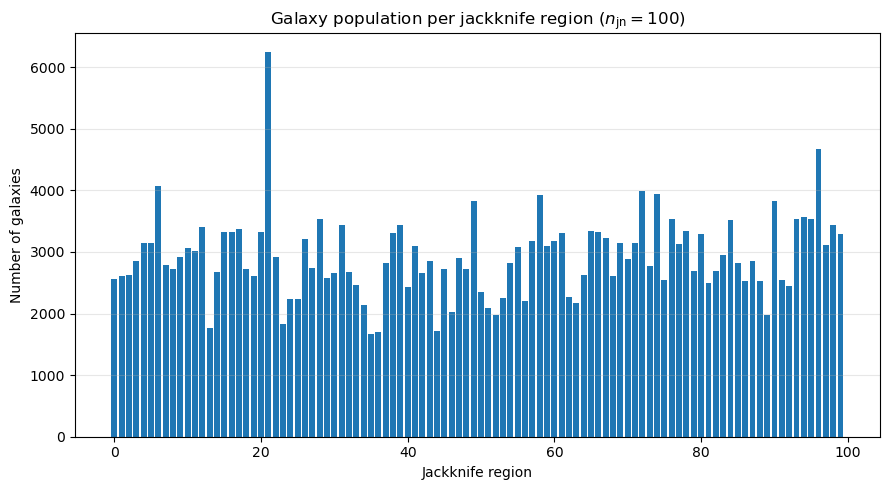

In [70]:
# ------------------------------------------------------------
# Galaxy count in each jackknife region
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.bar(
    unique_regions,
    counts,
    width=0.8
)

plt.xlabel("Jackknife region")
plt.ylabel("Number of galaxies")
plt.title(r"Galaxy population per jackknife region ($n_{\rm jn}=100$)")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

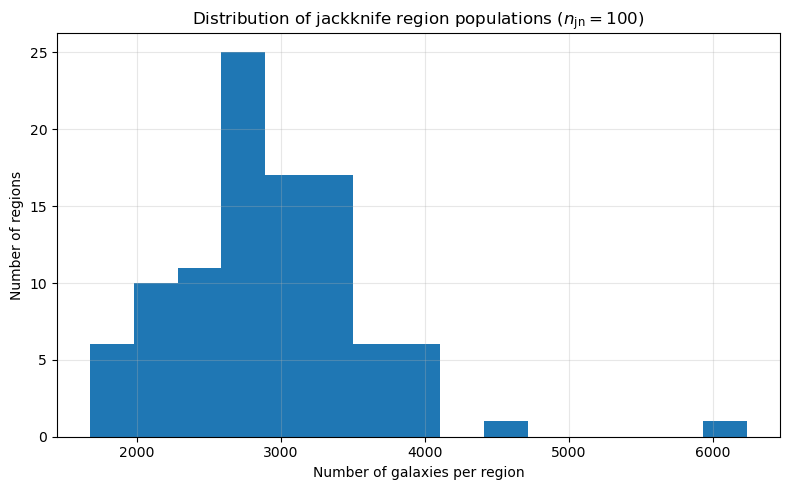

In [71]:
# ------------------------------------------------------------
# Distribution of galaxies per jackknife region
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.hist(
    counts,
    bins=15
)

plt.xlabel("Number of galaxies per region")
plt.ylabel("Number of regions")
plt.title(r"Distribution of jackknife region populations ($n_{\rm jn}=100$)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [72]:
# ------------------------------------------------------------
# Spatial extent of each jackknife region
# ------------------------------------------------------------

print("Jackknife region spatial extents")
print("=" * 80)

for region in unique_regions:

    mask = regions == region

    x = np.asarray(table["x"])[mask]
    y = np.asarray(table["y"])[mask]
    z = np.asarray(table["z"])[mask]

    print(
        f"Region {region:3d} | "
        f"N={len(x):5d} | "
        f"x=[{x.min():6.2f}, {x.max():6.2f}] | "
        f"y=[{y.min():6.2f}, {y.max():6.2f}] | "
        f"z=[{z.min():6.2f}, {z.max():6.2f}]"
    )

Jackknife region spatial extents
Region   0 | N= 2555 | x=[  0.01,  19.99] | y=[  0.01,  20.00] | z=[  0.00, 199.99]
Region   1 | N= 2611 | x=[  0.01,  20.00] | y=[ 20.01,  39.99] | z=[  0.00, 199.94]
Region   2 | N= 2627 | x=[  0.03,  20.00] | y=[ 40.00,  60.00] | z=[  0.10, 199.87]
Region   3 | N= 2852 | x=[  0.00,  20.00] | y=[ 60.00,  80.00] | z=[  0.34, 199.78]
Region   4 | N= 3142 | x=[  0.01,  20.00] | y=[ 80.01, 100.00] | z=[  0.37, 199.98]
Region   5 | N= 3148 | x=[  0.00,  20.00] | y=[100.00, 120.00] | z=[  0.06, 199.97]
Region   6 | N= 4075 | x=[  0.00,  20.00] | y=[120.00, 140.00] | z=[  0.18, 199.99]
Region   7 | N= 2787 | x=[  0.01,  20.00] | y=[140.01, 160.00] | z=[  0.08, 199.99]
Region   8 | N= 2724 | x=[  0.00,  19.98] | y=[160.00, 180.00] | z=[  0.05, 199.82]
Region   9 | N= 2916 | x=[  0.02,  19.99] | y=[180.00, 200.00] | z=[  0.10, 199.96]
Region  10 | N= 3062 | x=[ 20.00,  39.99] | y=[  0.03,  19.97] | z=[  0.09, 200.00]
Region  11 | N= 3022 | x=[ 20.00,  39.99] |

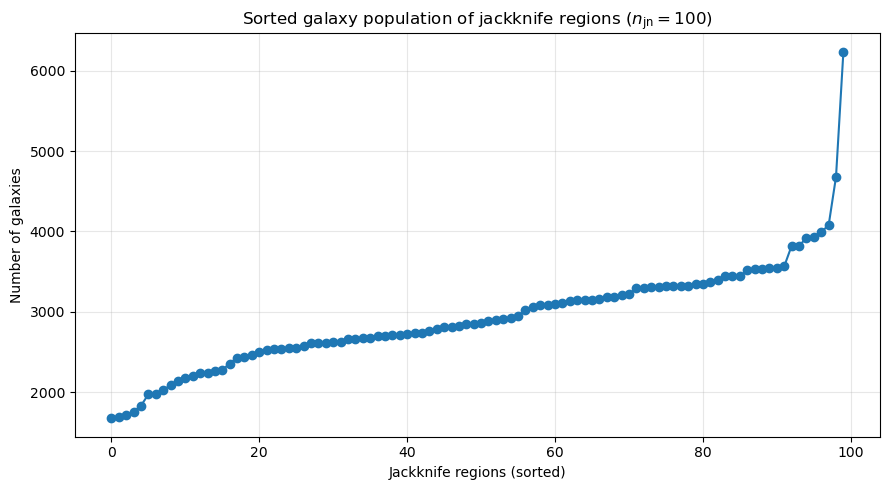

In [73]:
# ------------------------------------------------------------
# Sorted jackknife region populations
# ------------------------------------------------------------

order = np.argsort(counts)

plt.figure(figsize=(9, 5))

plt.plot(
    np.arange(len(counts)),
    counts[order],
    'o-'
)

plt.xlabel("Jackknife regions (sorted)")
plt.ylabel("Number of galaxies")
plt.title(r"Sorted galaxy population of jackknife regions ($n_{\rm jn}=100$)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [74]:
# ------------------------------------------------------------
# Jackknife region density contrast
# ------------------------------------------------------------

mean_count = np.mean(counts)

delta_jn = (counts - mean_count) / mean_count

print("Jackknife region density contrast")
print("=" * 65)

print(f"Mean galaxy count : {mean_count:,.2f}")
print(f"Min density contrast : {np.min(delta_jn):+.4f}")
print(f"Max density contrast : {np.max(delta_jn):+.4f}")
print(f"Std density contrast : {np.std(delta_jn):.4f}")

print("\nMost underdense regions:")
print("-" * 65)

for idx in np.argsort(delta_jn)[:10]:
    print(
        f"Region {unique_regions[idx]:3d} | "
        f"N = {counts[idx]:5d} | "
        f"delta = {delta_jn[idx]:+.4f}"
    )

print("\nMost overdense regions:")
print("-" * 65)

for idx in np.argsort(delta_jn)[-10:][::-1]:
    print(
        f"Region {unique_regions[idx]:3d} | "
        f"N = {counts[idx]:5d} | "
        f"delta = {delta_jn[idx]:+.4f}"
    )

Jackknife region density contrast
Mean galaxy count : 2,925.92
Min density contrast : -0.4282
Max density contrast : +1.1323
Std density contrast : 0.2241

Most underdense regions:
-----------------------------------------------------------------
Region  35 | N =  1673 | delta = -0.4282
Region  36 | N =  1696 | delta = -0.4204
Region  44 | N =  1713 | delta = -0.4145
Region  13 | N =  1758 | delta = -0.3992
Region  23 | N =  1830 | delta = -0.3746
Region  52 | N =  1972 | delta = -0.3260
Region  89 | N =  1981 | delta = -0.3229
Region  46 | N =  2023 | delta = -0.3086
Region  51 | N =  2089 | delta = -0.2860
Region  34 | N =  2139 | delta = -0.2689

Most overdense regions:
-----------------------------------------------------------------
Region  21 | N =  6239 | delta = +1.1323
Region  96 | N =  4679 | delta = +0.5992
Region   6 | N =  4075 | delta = +0.3927
Region  72 | N =  3996 | delta = +0.3657
Region  74 | N =  3935 | delta = +0.3449
Region  58 | N =  3919 | delta = +0.3394
Region

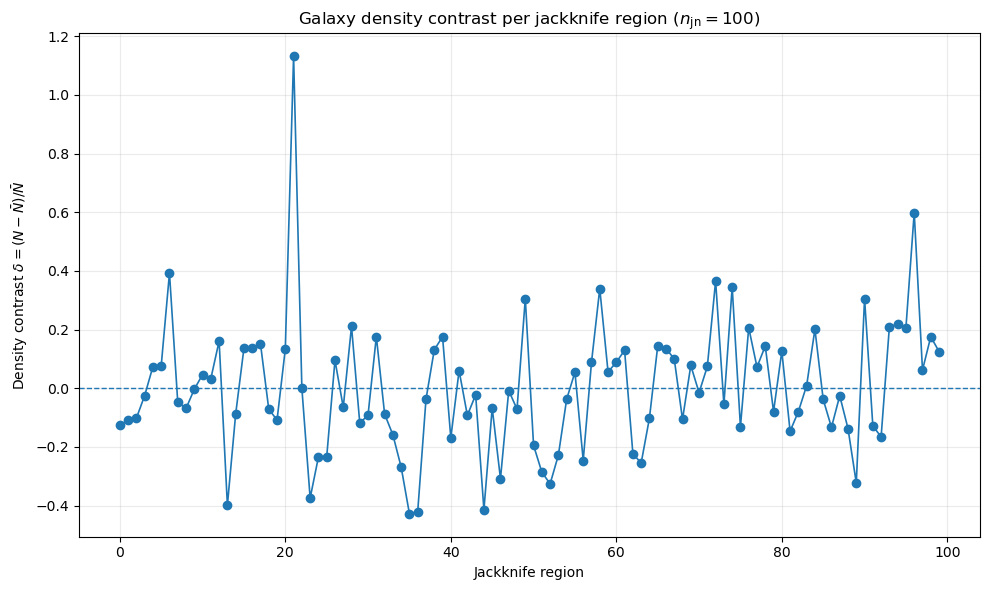

In [75]:
# ------------------------------------------------------------
# Density contrast of jackknife regions
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    unique_regions,
    delta_jn,
    marker="o",
    linewidth=1.2
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Jackknife region")
plt.ylabel(r"Density contrast $\delta = (N-\bar{N})/\bar{N}$")
plt.title(r"Galaxy density contrast per jackknife region ($n_{\rm jn}=100$)")

plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

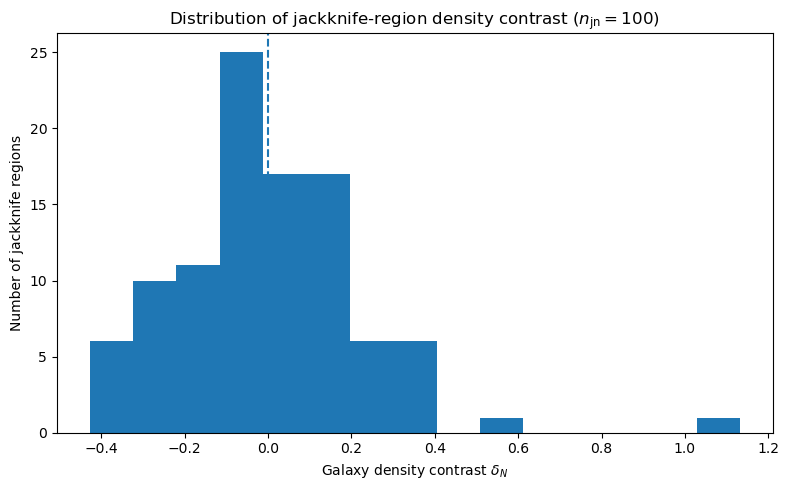

In [76]:
# ------------------------------------------------------------
# Distribution of jackknife-region density contrast
# ------------------------------------------------------------

delta_N = counts / np.mean(counts) - 1.0

plt.figure(figsize=(8, 5))

plt.hist(delta_N, bins=15)

plt.axvline(0.0, linestyle="--", linewidth=1.5)

plt.xlabel(r"Galaxy density contrast $\delta_N$")
plt.ylabel("Number of jackknife regions")
plt.title(r"Distribution of jackknife-region density contrast ($n_{\rm jn}=100$)")

plt.tight_layout()
plt.show()

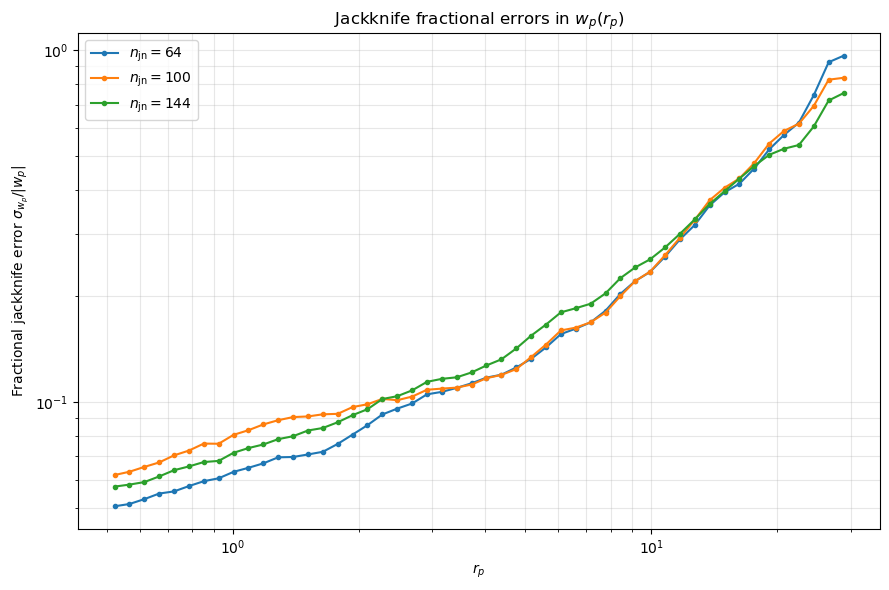

In [77]:
# ------------------------------------------------------------
# Compare fractional wp jackknife errors for all njn
# ------------------------------------------------------------

jk_files = {
    64: "results/wp_jackknife_njn64_Mr18_seed10.npz",
    100: "results/wp_jackknife_njn100_Mr18_seed10.npz",
    144: "results/wp_jackknife_njn144_Mr18_seed10.npz",
}

plt.figure(figsize=(9, 6))

for njn, path in jk_files.items():

    data = np.load(path)

    rp_jk = data["rp"]
    wp_mean_jk = data["wp_mean"]
    diag_err_jk = data["diag_err"]

    fractional_error = diag_err_jk / np.abs(wp_mean_jk)

    plt.plot(
        rp_jk,
        fractional_error,
        marker="o",
        markersize=3,
        label=fr"$n_{{\rm jn}}={njn}$"
    )

plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"$r_p$")
plt.ylabel(r"Fractional jackknife error $\sigma_{w_p}/|w_p|$")
plt.title(r"Jackknife fractional errors in $w_p(r_p)$")

plt.legend()
plt.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

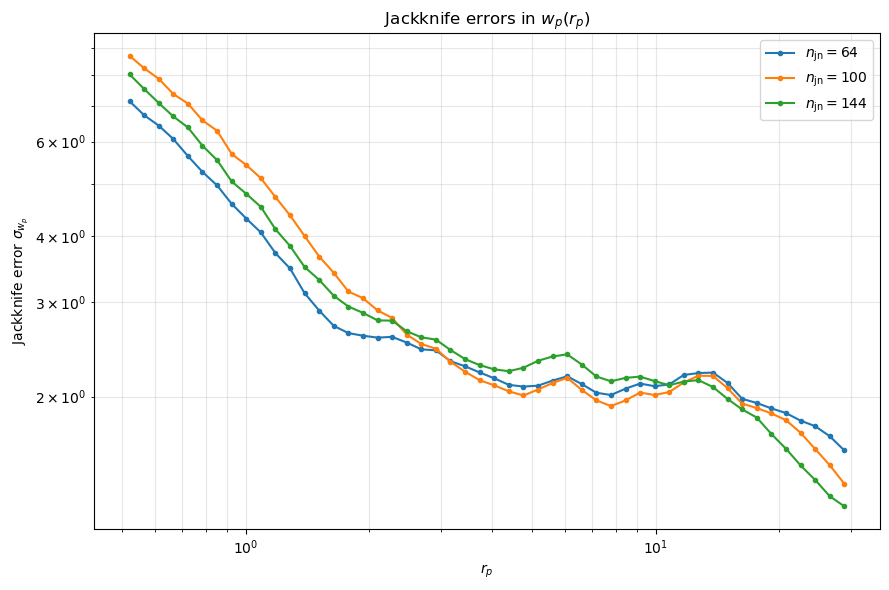

In [78]:
# ------------------------------------------------------------
# Compare absolute jackknife errors in wp(rp)
# ------------------------------------------------------------

jk_files = {
    64: "results/wp_jackknife_njn64_Mr18_seed10.npz",
    100: "results/wp_jackknife_njn100_Mr18_seed10.npz",
    144: "results/wp_jackknife_njn144_Mr18_seed10.npz",
}

plt.figure(figsize=(9, 6))

for njn, path in jk_files.items():

    data = np.load(path)

    rp_jk = data["rp"]
    diag_err_jk = data["diag_err"]

    plt.plot(
        rp_jk,
        diag_err_jk,
        marker="o",
        markersize=3,
        label=fr"$n_{{\rm jn}}={njn}$"
    )

plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"$r_p$")
plt.ylabel(r"Jackknife error $\sigma_{w_p}$")
plt.title(r"Jackknife errors in $w_p(r_p)$")

plt.legend()
plt.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

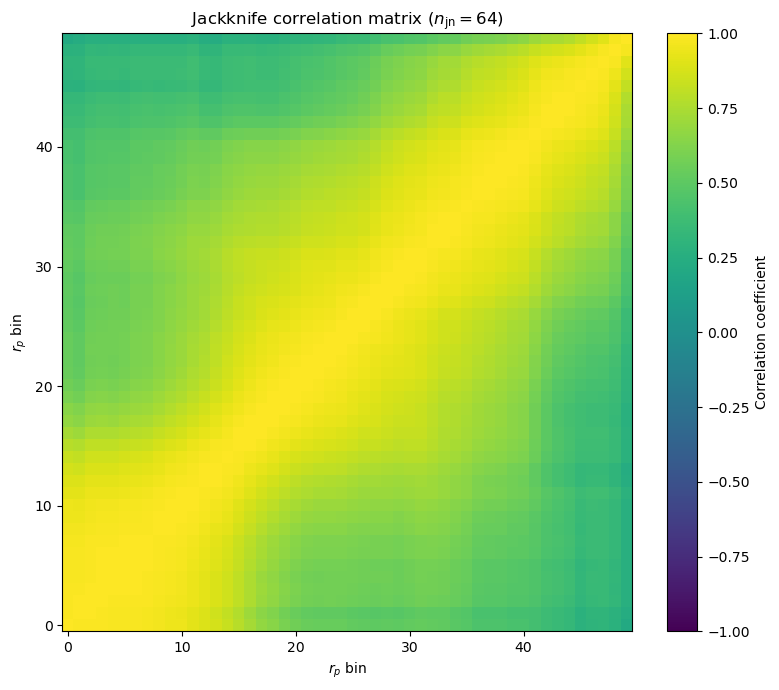

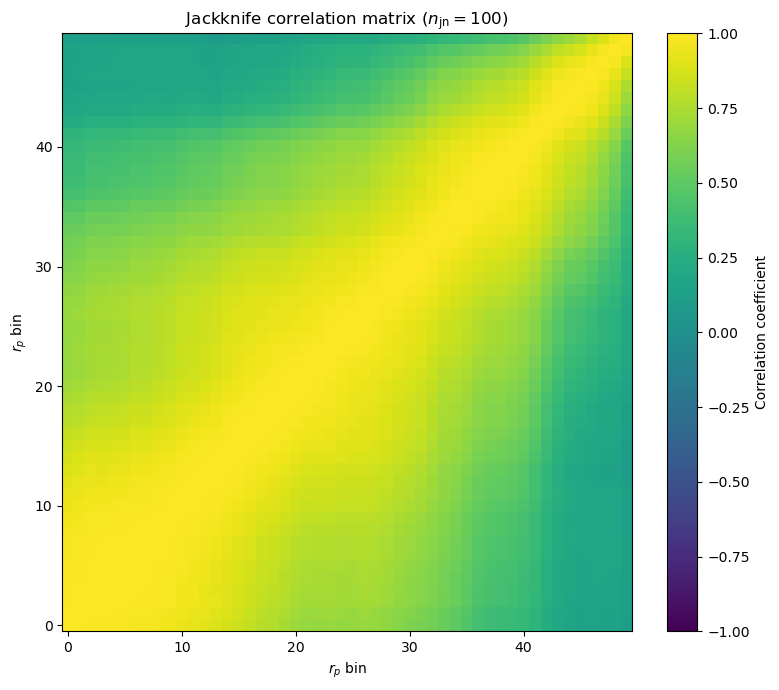

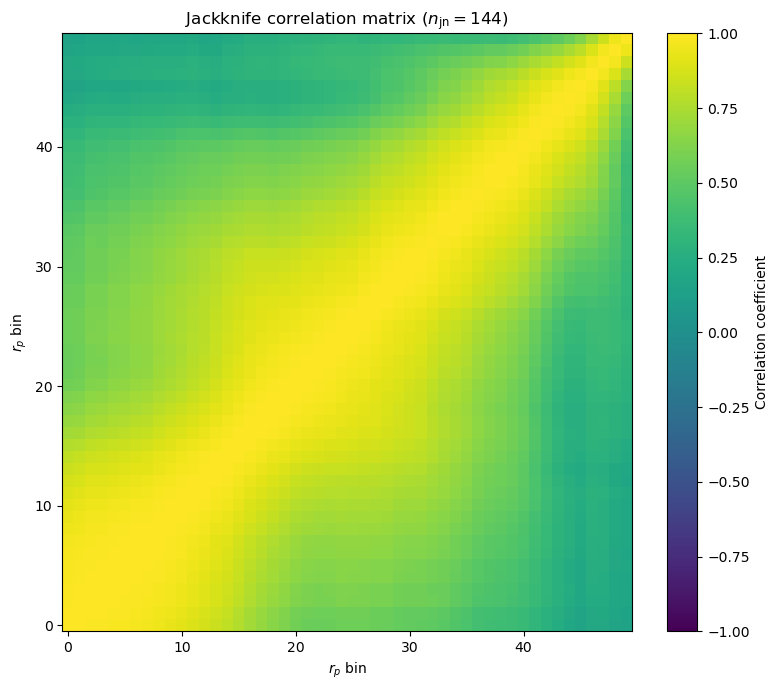

In [79]:
# ------------------------------------------------------------
# Correlation matrices for each jackknife resolution
# ------------------------------------------------------------

jk_files = {
    64: "results/wp_jackknife_njn64_Mr18_seed10.npz",
    100: "results/wp_jackknife_njn100_Mr18_seed10.npz",
    144: "results/wp_jackknife_njn144_Mr18_seed10.npz",
}

for njn, path in jk_files.items():

    data = np.load(path)

    cov_jk = data["cov"]

    # Convert covariance -> correlation matrix
    sigma = np.sqrt(np.diag(cov_jk))

    corr = cov_jk / np.outer(sigma, sigma)

    # --------------------------------------------------------
    # Separate figure for this njn
    # --------------------------------------------------------

    plt.figure(figsize=(8, 7))

    plt.imshow(
        corr,
        origin="lower",
        aspect="auto",
        interpolation="nearest",
        vmin=-1,
        vmax=1
    )

    plt.colorbar(label="Correlation coefficient")

    plt.xlabel(r"$r_p$ bin")
    plt.ylabel(r"$r_p$ bin")
    plt.title(fr"Jackknife correlation matrix ($n_{{\rm jn}}={njn}$)")

    plt.tight_layout()
    plt.show()

In [80]:
# ------------------------------------------------------------
# Quantitative covariance convergence
# ------------------------------------------------------------

jk_files = {
    64: "results/wp_jackknife_njn64_Mr18_seed10.npz",
    100: "results/wp_jackknife_njn100_Mr18_seed10.npz",
    144: "results/wp_jackknife_njn144_Mr18_seed10.npz",
}

covariances = {}

for njn, path in jk_files.items():
    data = np.load(path)
    covariances[njn] = data["cov"]


def relative_frobenius_difference(A, B):
    """
    ||A - B||_F / ||B||_F
    """
    return np.linalg.norm(A - B, ord="fro") / np.linalg.norm(B, ord="fro")


print("Covariance convergence")
print("=" * 65)

comparisons = [
    (64, 100),
    (100, 144),
    (64, 144),
]

for n1, n2 in comparisons:

    difference = relative_frobenius_difference(
        covariances[n1],
        covariances[n2]
    )

    print(
        f"{n1:3d} -> {n2:3d} : "
        f"{difference:.6f} "
        f"({difference * 100:.3f}%)"
    )

Covariance convergence
 64 -> 100 : 0.345754 (34.575%)
100 -> 144 : 0.235483 (23.548%)
 64 -> 144 : 0.196412 (19.641%)


In [81]:
# ------------------------------------------------------------
# Quantitative correlation-matrix convergence
# ------------------------------------------------------------

correlations = {}

for njn, cov in covariances.items():

    sigma = np.sqrt(np.diag(cov))

    corr = cov / np.outer(sigma, sigma)

    correlations[njn] = corr


def relative_frobenius_difference(A, B):
    return np.linalg.norm(A - B, ord="fro") / np.linalg.norm(B, ord="fro")


print("Correlation-matrix convergence")
print("=" * 65)

comparisons = [
    (64, 100),
    (100, 144),
    (64, 144),
]

for n1, n2 in comparisons:

    difference = relative_frobenius_difference(
        correlations[n1],
        correlations[n2]
    )

    print(
        f"{n1:3d} -> {n2:3d} : "
        f"{difference:.6f} "
        f"({difference * 100:.3f}%)"
    )
    

Correlation-matrix convergence
 64 -> 100 : 0.137213 (13.721%)
100 -> 144 : 0.074427 (7.443%)
 64 -> 144 : 0.110745 (11.074%)


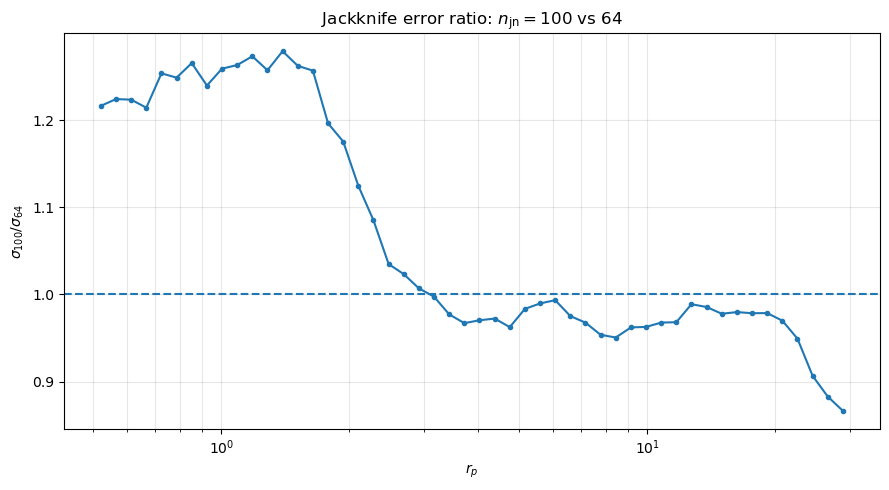

In [82]:
# ------------------------------------------------------------
# Jackknife error ratios
# ------------------------------------------------------------

errors = {}

for njn, path in jk_files.items():
    data = np.load(path)
    errors[njn] = data["diag_err"]


ratio_100_64 = errors[100] / errors[64]
ratio_144_100 = errors[144] / errors[100]
ratio_144_64 = errors[144] / errors[64]

# ------------------------------------------------------------
# 100 / 64
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    rp,
    ratio_100_64,
    marker="o",
    markersize=3
)

plt.axhline(1.0, linestyle="--", linewidth=1.5)

plt.xscale("log")

plt.xlabel(r"$r_p$")
plt.ylabel(r"$\sigma_{100}/\sigma_{64}$")
plt.title(r"Jackknife error ratio: $n_{\rm jn}=100$ vs $64$")

plt.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()


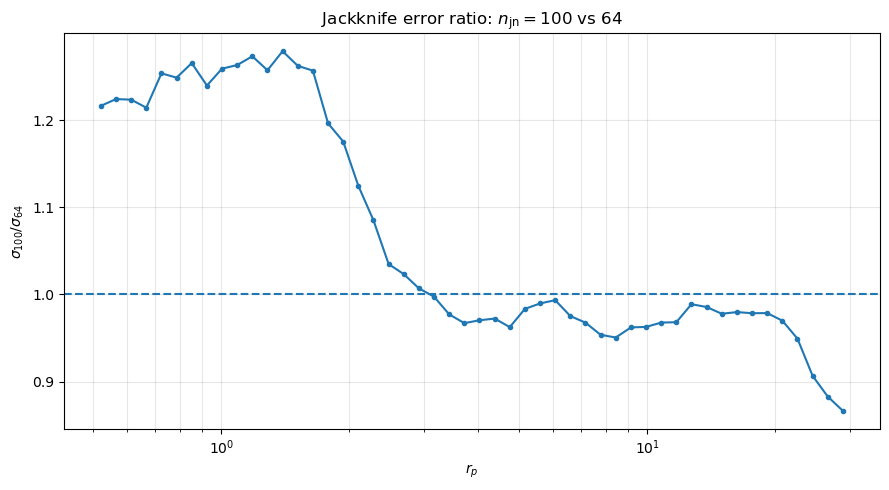

In [83]:
# ------------------------------------------------------------
# Jackknife error ratios
# ------------------------------------------------------------

errors = {}

for njn, path in jk_files.items():
    data = np.load(path)
    errors[njn] = data["diag_err"]


ratio_100_64 = errors[100] / errors[64]
ratio_144_100 = errors[144] / errors[100]
ratio_144_64 = errors[144] / errors[64]

# ------------------------------------------------------------
# 100 / 64
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    rp,
    ratio_100_64,
    marker="o",
    markersize=3
)

plt.axhline(1.0, linestyle="--", linewidth=1.5)

plt.xscale("log")

plt.xlabel(r"$r_p$")
plt.ylabel(r"$\sigma_{100}/\sigma_{64}$")
plt.title(r"Jackknife error ratio: $n_{\rm jn}=100$ vs $64$")

plt.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

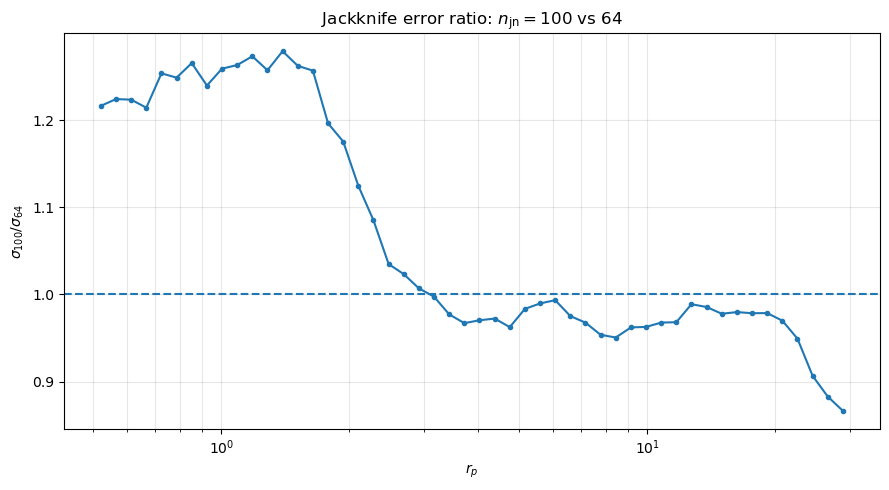

In [84]:
# ------------------------------------------------------------
# Jackknife error ratios
# ------------------------------------------------------------

errors = {}

for njn, path in jk_files.items():
    data = np.load(path)
    errors[njn] = data["diag_err"]


ratio_100_64 = errors[100] / errors[64]
ratio_144_100 = errors[144] / errors[100]
ratio_144_64 = errors[144] / errors[64]

# ------------------------------------------------------------
# 100 / 64
# ------------------------------------------------------------

plt.figure(figsize=(9, 5))

plt.plot(
    rp,
    ratio_100_64,
    marker="o",
    markersize=3
)

plt.axhline(1.0, linestyle="--", linewidth=1.5)

plt.xscale("log")

plt.xlabel(r"$r_p$")
plt.ylabel(r"$\sigma_{100}/\sigma_{64}$")
plt.title(r"Jackknife error ratio: $n_{\rm jn}=100$ vs $64$")

plt.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

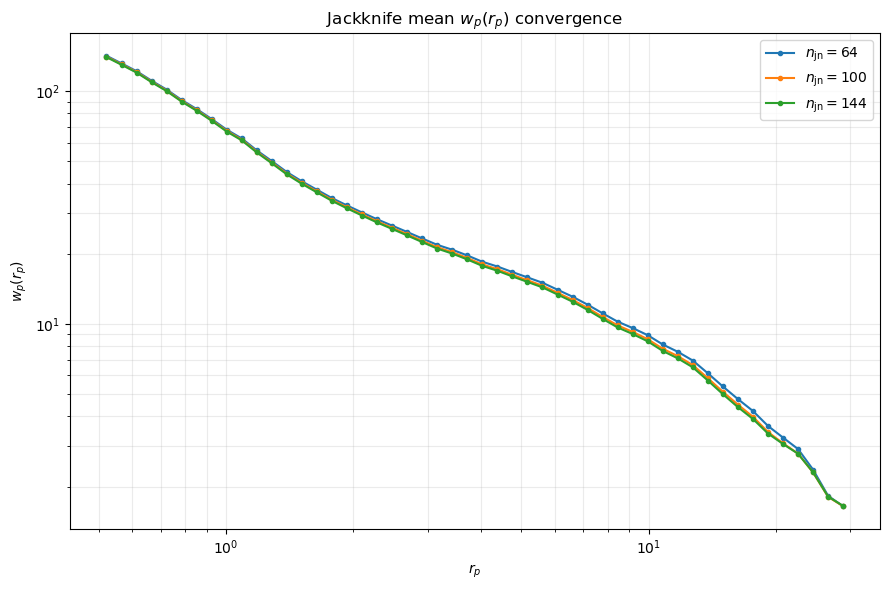

In [85]:
plt.figure(figsize=(9, 6))

for njn, data in jk_data.items():
    plt.plot(
        data["rp"],
        data["wp_mean"],
        marker="o",
        markersize=3,
        label=fr"$n_{{\rm jn}}={njn}$"
    )

plt.xscale("log")
plt.yscale("log")

plt.xlabel(r"$r_p$")
plt.ylabel(r"$w_p(r_p)$")
plt.title(r"Jackknife mean $w_p(r_p)$ convergence")

plt.grid(True, which="both", alpha=0.25)
plt.legend()

plt.tight_layout()
plt.show()

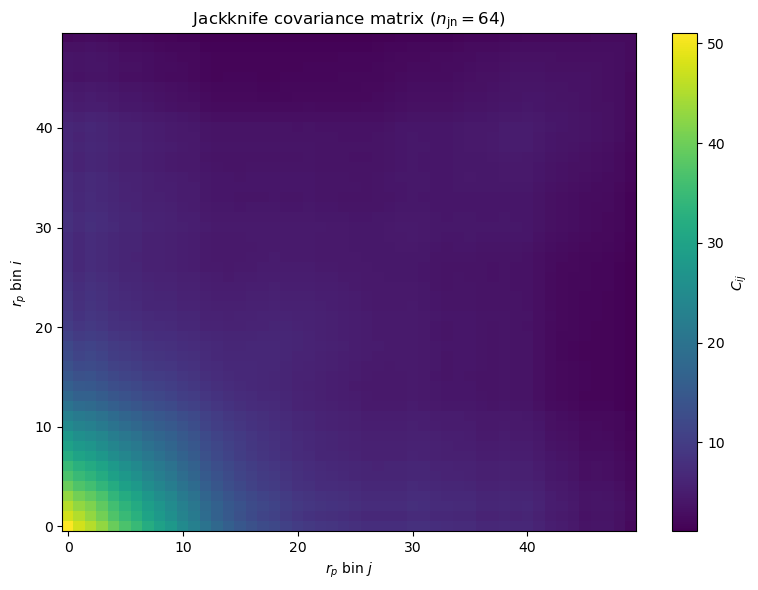

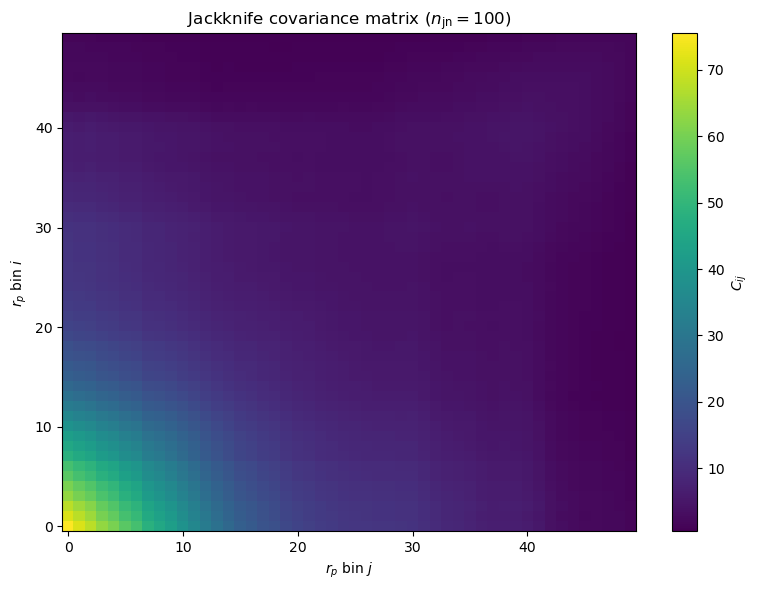

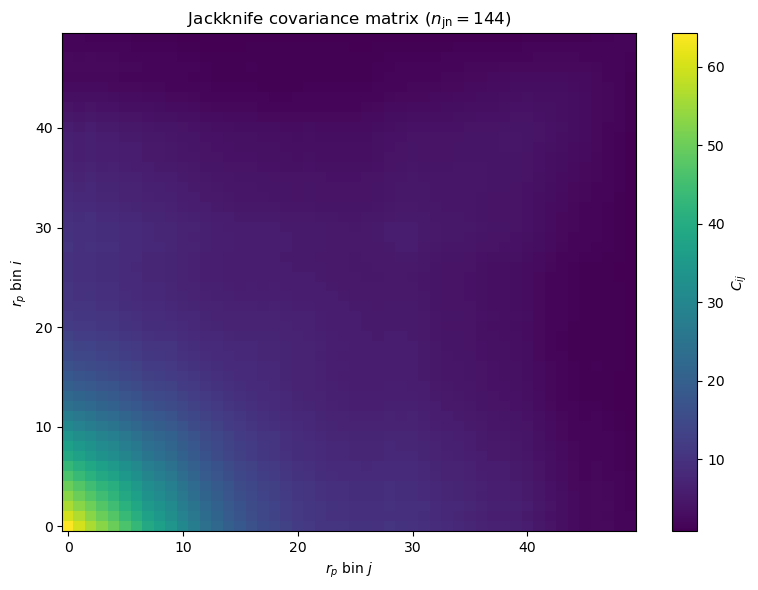

In [86]:
# ------------------------------------------------------------
# Covariance matrices for different jackknife resolutions
# ------------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np

covariances = {
    64: np.load("results/wp_jackknife_njn64_Mr18_seed10.npz")["cov"],
    100: np.load("results/wp_jackknife_njn100_Mr18_seed10.npz")["cov"],
    144: np.load("results/wp_jackknife_njn144_Mr18_seed10.npz")["cov"],
}

for njn, C in covariances.items():

    plt.figure(figsize=(8, 6))

    plt.imshow(
        C,
        origin="lower",
        aspect="auto",
        interpolation="nearest"
    )

    plt.colorbar(label=r"$C_{ij}$")

    plt.xlabel(r"$r_p$ bin $j$")
    plt.ylabel(r"$r_p$ bin $i$")
    plt.title(fr"Jackknife covariance matrix ($n_{{\rm jn}}={njn}$)")

    plt.tight_layout()
    plt.show()

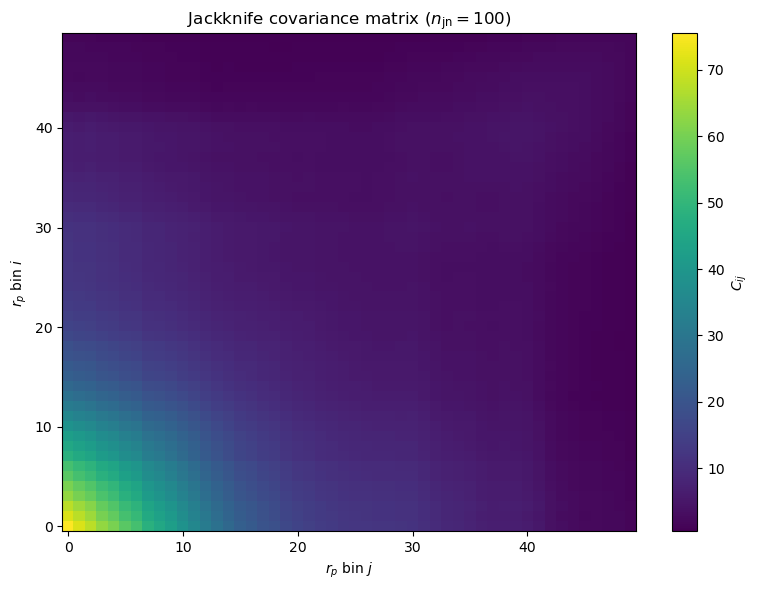

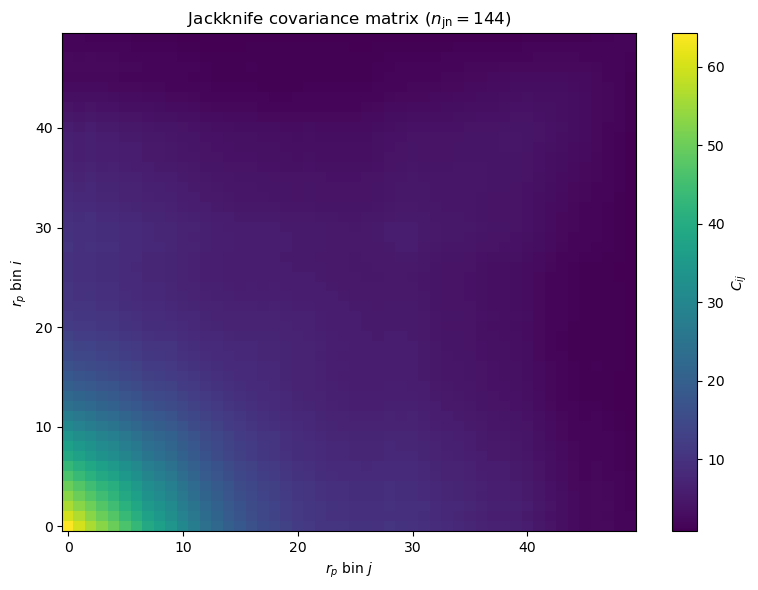

In [87]:
for njn in [100, 144]:

    C = np.load(
        f"results/wp_jackknife_njn{njn}_Mr18_seed10.npz"
    )["cov"]

    plt.figure(figsize=(8, 6))

    plt.imshow(
        C,
        origin="lower",
        aspect="auto",
        interpolation="nearest"
    )

    plt.colorbar(label=r"$C_{ij}$")

    plt.xlabel(r"$r_p$ bin $j$")
    plt.ylabel(r"$r_p$ bin $i$")
    plt.title(fr"Jackknife covariance matrix ($n_{{\rm jn}}={njn}$)")

    plt.tight_layout()
    plt.show()

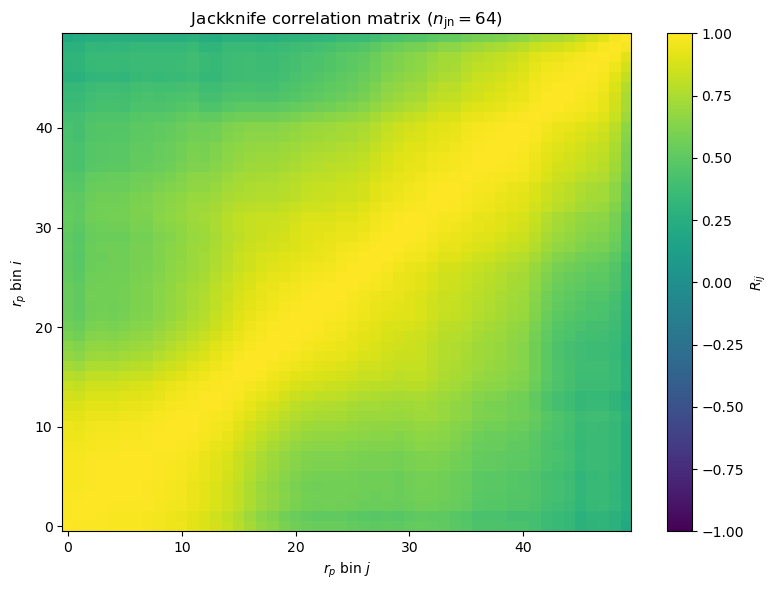

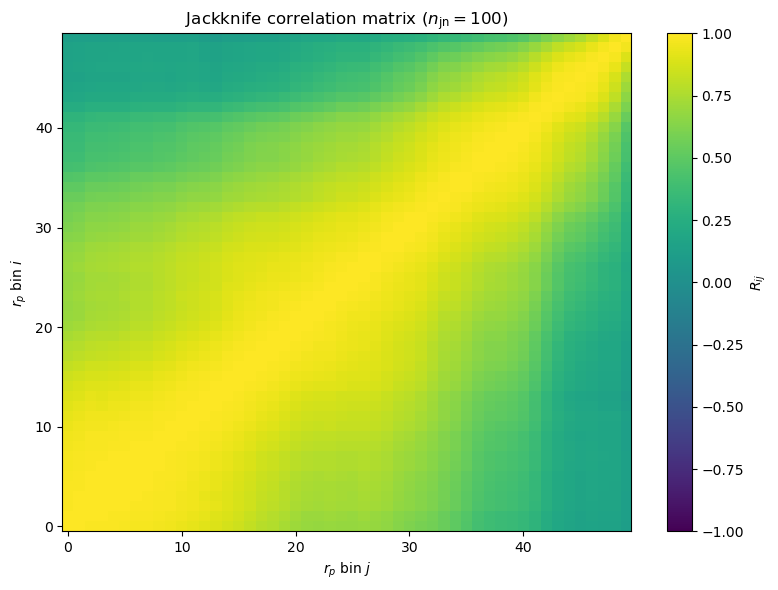

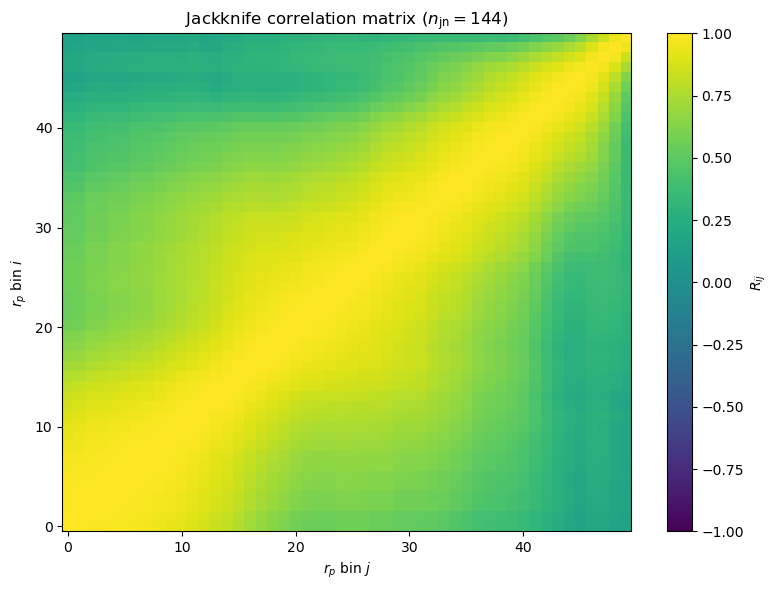

In [88]:
# ------------------------------------------------------------
# Individual correlation matrices
# ------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

for njn in [64, 100, 144]:

    C = np.load(
        f"results/wp_jackknife_njn{njn}_Mr18_seed10.npz"
    )["cov"]

    # Convert covariance -> correlation matrix
    diag = np.sqrt(np.diag(C))
    R = C / np.outer(diag, diag)

    plt.figure(figsize=(8, 6))

    plt.imshow(
        R,
        origin="lower",
        aspect="auto",
        interpolation="nearest",
        vmin=-1,
        vmax=1
    )

    plt.colorbar(label=r"$R_{ij}$")

    plt.xlabel(r"$r_p$ bin $j$")
    plt.ylabel(r"$r_p$ bin $i$")
    plt.title(
        fr"Jackknife correlation matrix ($n_{{\rm jn}}={njn}$)"
    )

    plt.tight_layout()
    plt.show()

In [98]:
# ------------------------------------------------------------
# M_cut response: individual perturbation plots
# ------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt

# Example:
# rp
# wp_fid
# wp_plus
# wp_minus

# Fractional response
frac_plus = (wp_plus - wp_fid) / wp_fid
frac_minus = (wp_minus - wp_fid) / wp_fid

NameError: name 'wp_plus' is not defined